In [12]:
!pip install scikit-learn==1.2.2 pyarrow tqdm matplotlib paramiko imbalanced-learn umap-learn xgboost lightgbm

INFO: pip is looking at multiple versions of imbalanced-learn to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 5.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0


In [38]:
import pandas as pd
import numpy as np
import os
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import gc
import warnings
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

In [39]:
data_dir = 'hapmap_data'
map_file = os.path.join(data_dir, 'hapmap3_r3_b36_fwd.consensus.qc.poly.map')
relationships_file = os.path.join(data_dir, 'relationships_w_pops_041510.txt')
output_dir = os.path.join(data_dir, 'sex_prediction_data')
os.makedirs(output_dir, exist_ok=True)

ped_files = glob.glob(os.path.join(data_dir, '**/*.ped'), recursive=True)
if not ped_files:
    raise FileNotFoundError("No PED files found. Make sure the archive was extracted correctly.")

print(f"Found {len(ped_files)} PED files for different populations")

Found 11 PED files for different populations


In [40]:
print("\nReading relationships and populations file...")
relationships_df = pd.read_csv(relationships_file, sep='\s+', low_memory=False)
print(f"Relationships file read. Dimensions: {relationships_df.shape}")

print("\nReading map file (SNPs information)...")
map_columns = ['CHR', 'SNP', 'GEN_DIST', 'POS']
map_df = pd.read_csv(map_file, sep='\s+', header=None, names=map_columns)
print(f"Map file read. Number of SNPs: {map_df.shape[0]}")

MAX_SNPS = 300000
if map_df.shape[0] > MAX_SNPS:
    print(f"\nUsing first {MAX_SNPS} SNPs out of {map_df.shape[0]} to speed up processing...")
    map_df = map_df.iloc[:MAX_SNPS]
    print(f"Number of SNPs limited. New SNP count: {map_df.shape[0]}")



Reading relationships and populations file...
Relationships file read. Dimensions: (1397, 7)

Reading map file (SNPs information)...
Map file read. Number of SNPs: 1457897

Using first 300000 SNPs out of 1457897 to speed up processing...
Number of SNPs limited. New SNP count: 300000


In [41]:
all_samples_info = []
population_labels = {}
sex_labels = {}

for ped_file in ped_files:
    file_basename = os.path.basename(ped_file)
    population = file_basename.split('.')[1] if len(file_basename.split('.')) > 2 else "Unknown"
    
    ped_columns = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENO']
    dtype_dict = {0: str, 1: str, 2: str, 3: str, 4: int, 5: int}
    
    ped_info_df = pd.read_csv(ped_file, sep='\s+', header=None, usecols=range(6), 
                             names=ped_columns, dtype=dtype_dict, low_memory=False)
    
    ped_info_df['FILE_POP'] = population
    
    all_samples_info.append(ped_info_df)
    
    for idx, row in ped_info_df.iterrows():
        population_labels[row['IID']] = population
        sex_labels[row['IID']] = row['SEX']

all_samples_df = pd.concat(all_samples_info, ignore_index=True)
print(f"Collected information for {all_samples_df.shape[0]} samples from {len(ped_files)} populations.")


Collected information for 1397 samples from 11 populations.


In [42]:
if 'SEX' not in all_samples_df.columns or all_samples_df['SEX'].isnull().all():
    raise ValueError("No sex data in PED files!")

sex_counts = all_samples_df['SEX'].value_counts()
print("\nSex distribution in the data:")
print(sex_counts)

valid_sex_mask = all_samples_df['SEX'].isin([1, 2])  # 1=male, 2=female
all_samples_df = all_samples_df[valid_sex_mask]
print(f"Data filtered to {all_samples_df.shape[0]} samples after excluding samples without valid sex information.")

sex_counts = all_samples_df['SEX'].value_counts()
print("\nSex distribution after filtering:")
print(sex_counts)




Sex distribution in the data:
SEX
2    714
1    683
Name: count, dtype: int64
Data filtered to 1397 samples after excluding samples without valid sex information.

Sex distribution after filtering:
SEX
2    714
1    683
Name: count, dtype: int64


In [43]:
merged_samples_df = pd.merge(
    all_samples_df,
    relationships_df,
    on='IID',
    how='left',
    suffixes=('_ped', '_rel')
)

samples_info_file = os.path.join(output_dir, 'all_samples_info.csv')
merged_samples_df.to_csv(samples_info_file, index=False)
print(f"Sample information saved to: {samples_info_file}")

Sample information saved to: hapmap_data/sex_prediction_data/all_samples_info.csv


In [44]:
def improved_encoding(genotype_data):
    """Improved encoding for genetic data using additive inheritance model"""
    encoded_data = np.zeros((genotype_data.shape[0], genotype_data.shape[1] // 2), dtype=np.float32)
    
    for i in range(0, genotype_data.shape[1], 2):
        allele1 = genotype_data[:, i]
        allele2 = genotype_data[:, i+1]
        snp_idx = i // 2
        
        unique_alleles, counts = np.unique(np.concatenate([allele1, allele2]), return_counts=True)
        
        if len(unique_alleles) > 0:
            ref_allele = unique_alleles[np.argmax(counts)]
            
            alt_count = np.zeros(allele1.shape[0], dtype=np.float32)
            alt_count += (allele1 != ref_allele) & (allele1 != '0')
            alt_count += (allele2 != ref_allele) & (allele2 != '0')
            
            encoded_data[:, snp_idx] = alt_count
    
    return encoded_data

In [45]:

valid_samples = all_samples_df['IID'].tolist()

all_genotype_data = []
all_samples_ids = []
all_sex_labels = []

for ped_file in tqdm(ped_files, desc="Processing PED files"):
    ped_columns = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENO']
    ped_info = pd.read_csv(ped_file, sep='\s+', header=None, usecols=range(6), 
                          names=ped_columns, low_memory=False)
    
    valid_mask = ped_info['IID'].isin(valid_samples) & ped_info['SEX'].isin([1, 2])
    if valid_mask.sum() == 0:
        print(f"Skipping file {os.path.basename(ped_file)} - no valid samples")
        continue
    
    ped_info = ped_info[valid_mask]
    
    n_samples = ped_info.shape[0]
    sample_ids = ped_info['IID'].tolist()
    sex_values = ped_info['SEX'].tolist()
    
    all_samples_ids.extend(sample_ids)
    all_sex_labels.extend(sex_values)
    
    total_columns = 6 + (MAX_SNPS * 2)
    
    try:
        column_indices = list(range(6)) + list(range(6, 6 + (MAX_SNPS * 2)))
        genotype_data = pd.read_csv(ped_file, sep='\s+', header=None, usecols=column_indices, low_memory=False)
        
        genotype_data = genotype_data[valid_mask].reset_index(drop=True)
        
        snp_data = genotype_data.iloc[:, 6:].values
        
        encoded_data = improved_encoding(snp_data)
        
        all_genotype_data.append(encoded_data)
        
        print(f"Processed {encoded_data.shape[0]} samples and {encoded_data.shape[1]} SNPs from file {os.path.basename(ped_file)}")
        
        del genotype_data, snp_data
        gc.collect()
        
    except Exception as e:
        print(f"Error processing file {ped_file}: {str(e)}")
        continue


Processing PED files:   9%|▉         | 1/11 [01:48<18:06, 108.67s/it]

Processed 109 samples and 300000 SNPs from file hapmap3_r3_b36_fwd.CHD.qc.poly.ped


Processing PED files:  18%|█▊        | 2/11 [03:42<16:44, 111.64s/it]

Processed 137 samples and 300000 SNPs from file hapmap3_r3_b36_fwd.CHB.qc.poly.ped


Processing PED files:  27%|██▋       | 3/11 [04:59<12:47, 95.94s/it] 

...

Processed 101 samples and 300000 SNPs from file hapmap3_r3_b36_fwd.GIH.qc.poly.ped


Processing PED files:  91%|█████████ | 10/11 [17:02<01:38, 98.58s/it]

Processed 113 samples and 300000 SNPs from file hapmap3_r3_b36_fwd.JPT.qc.poly.ped


Processing PED files: 100%|██████████| 11/11 [19:00<00:00, 103.66s/it]

Processed 165 samples and 300000 SNPs from file hapmap3_r3_b36_fwd.CEU.qc.poly.ped


In [46]:
all_genotypes = np.vstack(all_genotype_data)
print(f"Genetic data combined. Dimensions: {all_genotypes.shape}")

del all_genotype_data
gc.collect()

samples_df = pd.DataFrame({
    'IID': all_samples_ids,
    'SEX': all_sex_labels
})

samples_df['Population'] = samples_df['IID'].map(population_labels)

print("\nSex distribution in final data:")
print(samples_df['SEX'].value_counts())
print("\nSex distribution by population:")
print(pd.crosstab(samples_df['Population'], samples_df['SEX']))

Genetic data combined. Dimensions: (1397, 300000)

Sex distribution in final data:
SEX
2    714
1    683
Name: count, dtype: int64

Sex distribution by population:
SEX           1   2
Population         
ASW          41  46
CEU          80  85
CHB          53  84
CHD          50  59
GIH          58  43
JPT          57  56
LWK          50  60
MEX          38  48
MKK          95  89
TSI          53  49
YRI         108  95


In [47]:
print("\nSelecting best SNPs for sex differentiation...")
X = all_genotypes
y = samples_df['SEX'].values

selector = SelectKBest(f_classif, k=10000)
X_selected = selector.fit_transform(X, y)

print(f"Selected {X_selected.shape[1]} SNPs out of {X.shape[1]} SNPs.")
print(f"Dimensions of selected data: {X_selected.shape}")

selected_indices = selector.get_support(indices=True)
selected_snps = map_df.iloc[selected_indices]
selected_snps.to_csv(os.path.join(output_dir, 'sex_selected_snps.csv'), index=False)
print(f"List of selected SNPs saved to: {os.path.join(output_dir, 'sex_selected_snps.csv')}")



Selecting best SNPs for sex differentiation...
Selected 10000 SNPs out of 300000 SNPs.
Dimensions of selected data: (1397, 10000)
List of selected SNPs saved to: hapmap_data/sex_prediction_data/sex_selected_snps.csv


CHR
1    4046
2    3844
3    2110
Name: count, dtype: int64


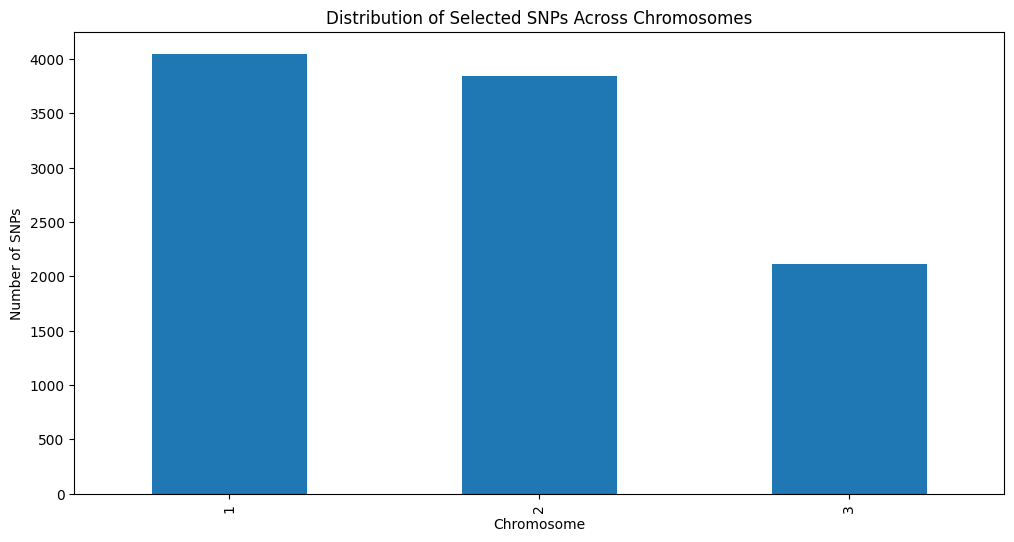

In [48]:
chr_counts = selected_snps['CHR'].value_counts().sort_index()
print(chr_counts)

plt.figure(figsize=(12, 6))
chr_counts.plot(kind='bar')
plt.title('Distribution of Selected SNPs Across Chromosomes')
plt.xlabel('Chromosome')
plt.ylabel('Number of SNPs')
plt.savefig(os.path.join(output_dir, 'sex_snps_distribution.png'))


Dimensions reduced to 50 principal components.
Explained variance ratio: 0.2661


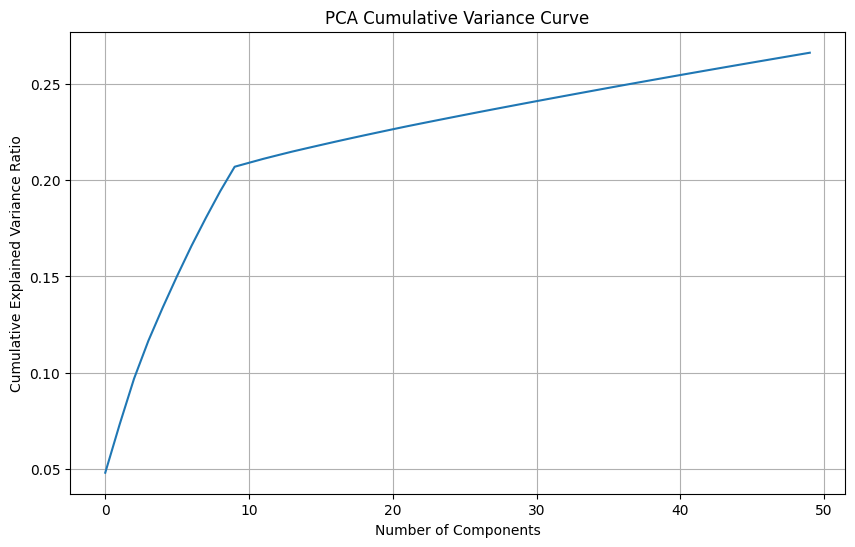

In [49]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_selected)

print(f"Dimensions reduced to {X_pca.shape[1]} principal components.")
print(f"Explained variance ratio: {sum(pca.explained_variance_ratio_):.4f}")

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA Cumulative Variance Curve')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'sex_pca_variance.png'))

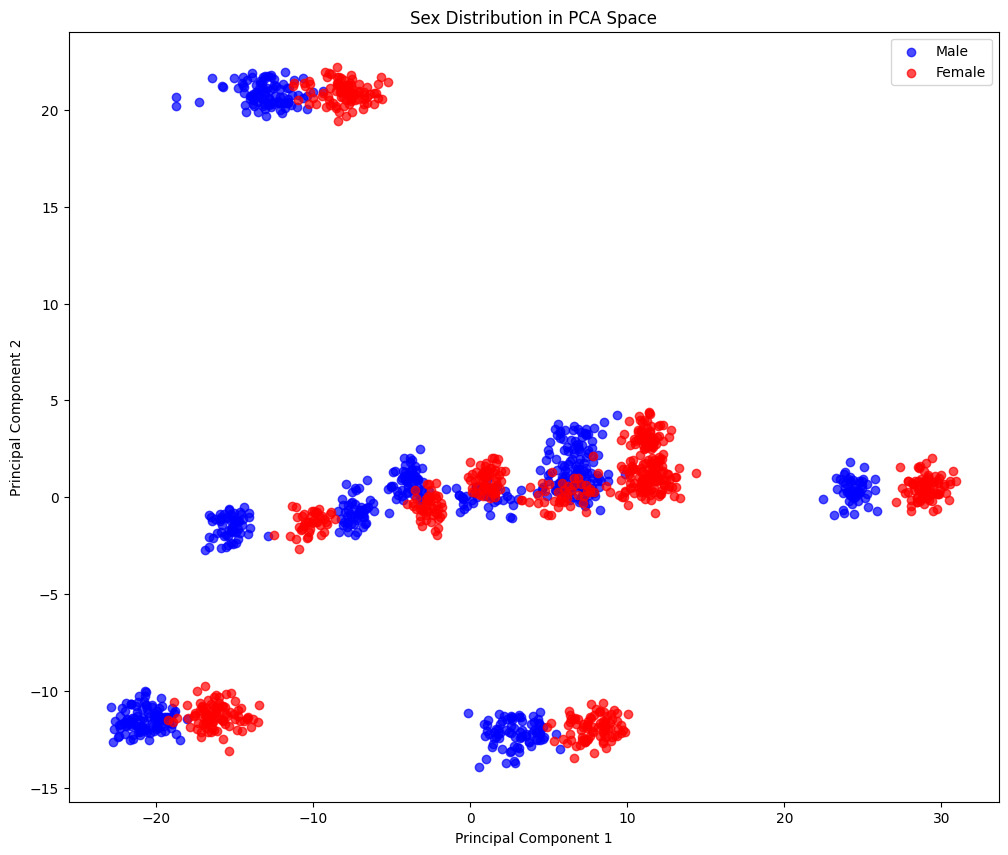

In [50]:
plt.figure(figsize=(12, 10))
sex_colors = {1: 'blue', 2: 'red'}  # 1=male, 2=female
sex_labels = {1: 'Male', 2: 'Female'}

for sex_value in [1, 2]:
    sex_mask = samples_df['SEX'] == sex_value
    plt.scatter(
        X_pca[sex_mask, 0], 
        X_pca[sex_mask, 1],
        c=sex_colors[sex_value],
        label=sex_labels[sex_value], 
        alpha=0.7
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Sex Distribution in PCA Space')
plt.legend()
plt.savefig(os.path.join(output_dir, 'sex_pca_distribution.png'))


In [51]:
features_df = pd.DataFrame(X_pca, columns=[f'PC_{i+1}' for i in range(X_pca.shape[1])])
features_df['IID'] = samples_df['IID'].values
features_df['SEX'] = samples_df['SEX'].values
features_df['Population'] = samples_df['Population'].values

features_file = os.path.join(output_dir, 'sex_features_pca.csv')
features_df.to_csv(features_file, index=False)
print(f"Extracted features saved to: {features_file}")

Extracted features saved to: hapmap_data/sex_prediction_data/sex_features_pca.csv


In [52]:
feature_columns = [f'PC_{i+1}' for i in range(X_pca.shape[1])]
le_pop = LabelEncoder()
features_df['Population_encoded'] = le_pop.fit_transform(features_df['Population'])
feature_columns.append('Population_encoded')

X = features_df[feature_columns].values
y = features_df['SEX'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 977 samples
Test set: 420 samples


In [53]:
if len(np.unique(y_train)) > 1 and abs(sum(y_train == 1) - sum(y_train == 2)) > 100:
    print("\nApplying SMOTE to handle data imbalance...")
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    
    print(f"Size of training set after SMOTE: {X_train_balanced.shape[0]} samples")
    print("Sex distribution after SMOTE:")
    for sex_value, count in zip(*np.unique(y_train_balanced, return_counts=True)):
        print(f"{sex_labels.get(sex_value, sex_value)}: {count} samples")
else:
    X_train_balanced = X_train
    y_train_balanced = y_train
    print("No significant imbalance in the data, so SMOTE was not applied.")

No significant imbalance in the data, so SMOTE was not applied.


In [54]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 20],
    'model__min_samples_split': [2, 5],
    'model__class_weight': [None, 'balanced']
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

print("Searching for best parameters...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train_balanced, y_train_balanced)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Searching for best parameters...
Best parameters: {'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best cross-validation accuracy: 0.9181



Classification report:
              precision    recall  f1-score   support

    Male (1)       0.89      0.94      0.91       205
  Female (2)       0.94      0.89      0.91       215

    accuracy                           0.91       420
   macro avg       0.92      0.91      0.91       420
weighted avg       0.92      0.91      0.91       420


Overall model accuracy: 0.9143


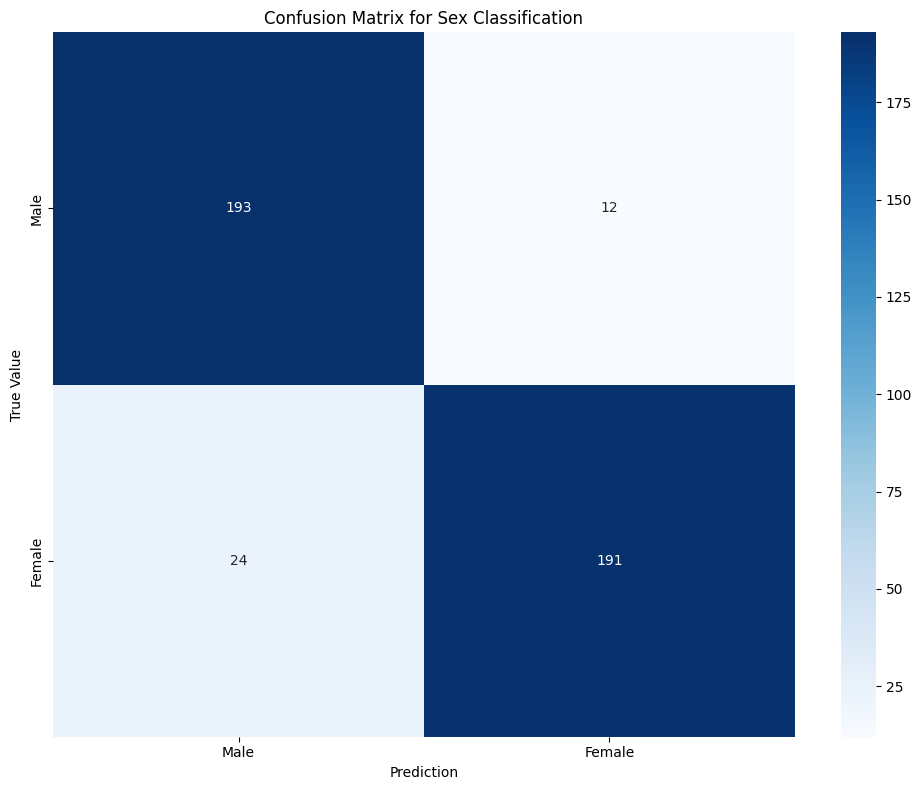

In [55]:
y_pred = best_model.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['Male (1)', 'Female (2)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Male', 'Female'],
            yticklabels=['Male', 'Female'])
plt.xlabel('Prediction')
plt.ylabel('True Value')
plt.title('Confusion Matrix for Sex Classification')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'sex_confusion_matrix.png'))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall model accuracy: {accuracy:.4f}")

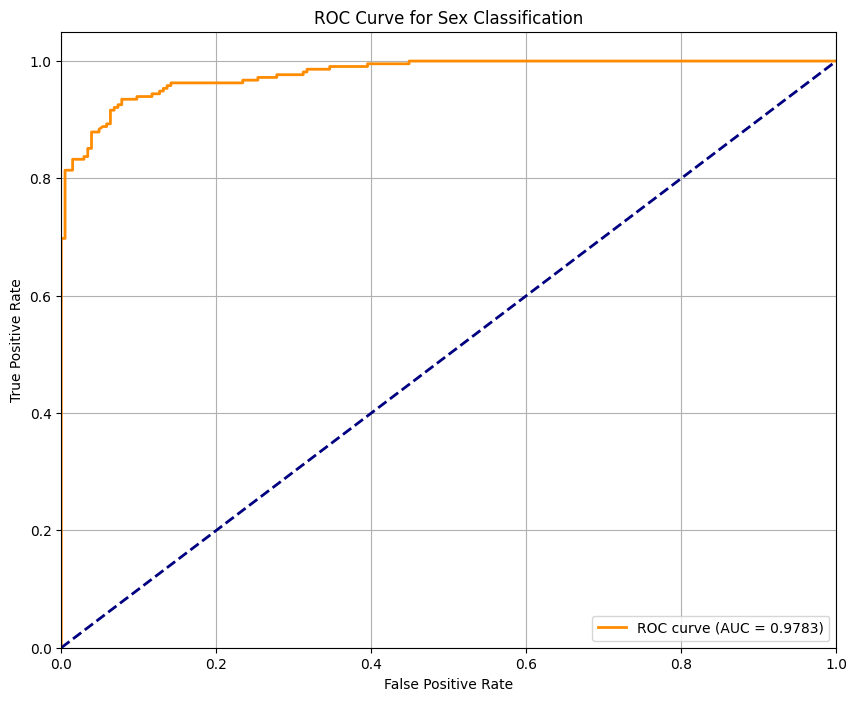

In [56]:
if hasattr(best_model, 'predict_proba'):
    y_prob = best_model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=2)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Sex Classification')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, 'sex_roc_curve.png'))


Top 10 features for sex classification:
PC_14: 0.1941
PC_12: 0.1666
PC_11: 0.1052
PC_1: 0.0834
PC_22: 0.0317
PC_13: 0.0277
PC_4: 0.0242
PC_3: 0.0145
PC_7: 0.0133
PC_17: 0.0128


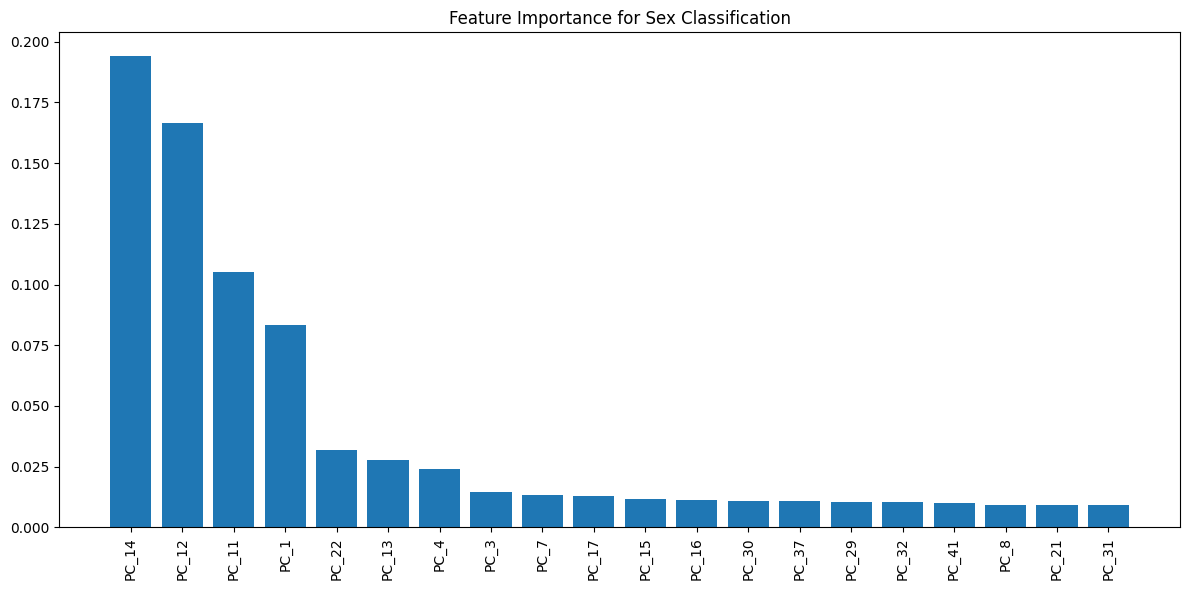

In [57]:
if hasattr(best_model['model'], 'feature_importances_'):
    importances = best_model['model'].feature_importances_
    indices = np.argsort(importances)[::-1]
    
    print("\nTop 10 features for sex classification:")
    for i in range(min(10, len(feature_columns))):
        print(f"{feature_columns[indices[i]]}: {importances[indices[i]]:.4f}")
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(min(20, len(feature_columns))), 
            importances[indices[:20]], 
            align='center')
    plt.xticks(range(min(20, len(feature_columns))), 
              [feature_columns[i] for i in indices[:20]], 
              rotation=90)
    plt.title('Feature Importance for Sex Classification')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'sex_feature_importance.png'))


In [58]:
features_df['Predicted_SEX'] = best_model.predict(features_df[feature_columns].values)

for pop in features_df['Population'].unique():
    pop_mask = features_df['Population'] == pop
    pop_data = features_df[pop_mask]
    if not pop_data.empty:
        pop_accuracy = accuracy_score(pop_data['SEX'], pop_data['Predicted_SEX'])
        print(f"{pop}: accuracy = {pop_accuracy:.4f} ({sum(pop_mask)} samples)")

CHD: accuracy = 0.9908 (109 samples)
CHB: accuracy = 0.9854 (137 samples)
MEX: accuracy = 0.9419 (86 samples)
YRI: accuracy = 0.9606 (203 samples)
LWK: accuracy = 1.0000 (110 samples)
ASW: accuracy = 0.9425 (87 samples)
TSI: accuracy = 1.0000 (102 samples)
MKK: accuracy = 0.9620 (184 samples)
GIH: accuracy = 0.9901 (101 samples)
JPT: accuracy = 0.9823 (113 samples)
CEU: accuracy = 0.9697 (165 samples)


In [59]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
svm = SVC(probability=True, class_weight='balanced', random_state=42)
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('mlp', mlp)
    ],
    voting='soft'
)

ensemble_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ensemble)
])

print("Training ensemble model...")
ensemble_pipeline.fit(X_train_balanced, y_train_balanced)

Training ensemble model...


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 VotingClassifier(estimators=[('rf',
                                               RandomForestClassifier(class_weight='balanced',
                                                                      n_estimators=200,
                                                                      random_state=42)),
                                              ('svm',
                                               SVC(class_weight='balanced',
                                                   probability=True,
                                                   random_state=42)),
                                              ('mlp',
                                               MLPClassifier(hidden_layer_sizes=(100,
                                                                                 50),
                                                             max_iter=1000,
                                                             random_state=42))],
                                  voting='soft'))])

Ensemble model accuracy: 0.9143
              precision    recall  f1-score   support

    Male (1)       0.90      0.93      0.91       205
  Female (2)       0.93      0.90      0.91       215

    accuracy                           0.91       420
   macro avg       0.91      0.91      0.91       420
weighted avg       0.91      0.91      0.91       420



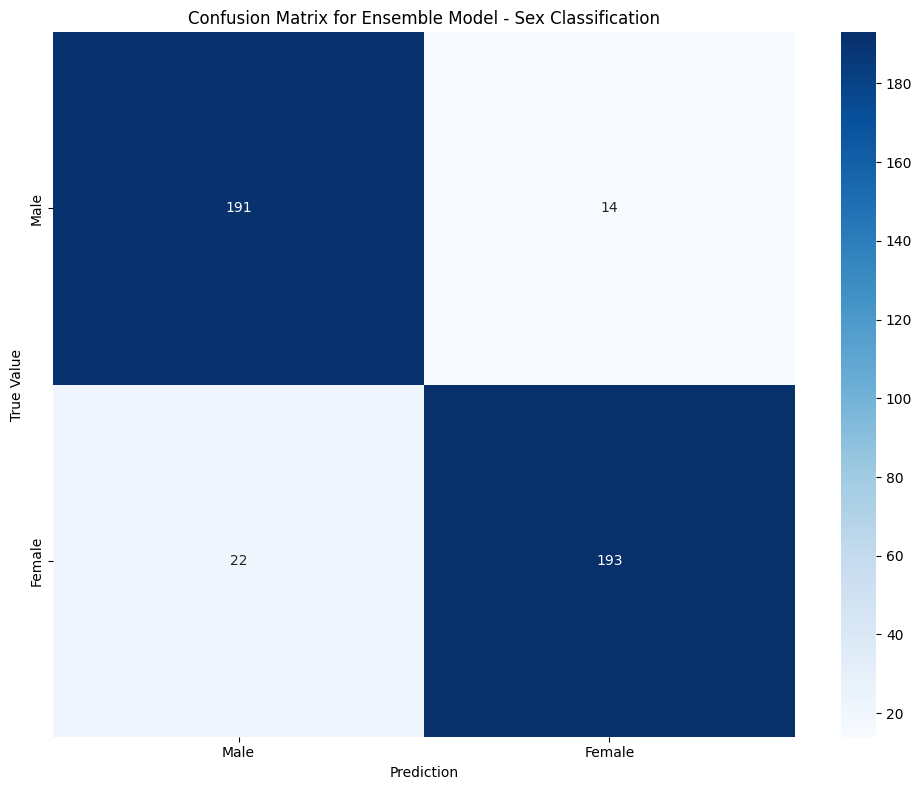

In [60]:
ensemble_preds = ensemble_pipeline.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, ensemble_preds)

print(f"Ensemble model accuracy: {ensemble_accuracy:.4f}")
print(classification_report(y_test, ensemble_preds, target_names=['Male (1)', 'Female (2)']))

cm_ensemble = confusion_matrix(y_test, ensemble_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Male', 'Female'],
            yticklabels=['Male', 'Female'])
plt.xlabel('Prediction')
plt.ylabel('True Value')
plt.title('Confusion Matrix for Ensemble Model - Sex Classification')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'sex_ensemble_confusion_matrix.png'))


In [61]:
import joblib
best_model_file = os.path.join(output_dir, 'best_sex_model.pkl')
ensemble_model_file = os.path.join(output_dir, 'ensemble_sex_model.pkl')

joblib.dump(best_model, best_model_file)
joblib.dump(ensemble_pipeline, ensemble_model_file)

print(f"\nBest model saved to: {best_model_file}")
print(f"Ensemble model saved to: {ensemble_model_file}")


Best model saved to: hapmap_data/sex_prediction_data/best_sex_model.pkl
Ensemble model saved to: hapmap_data/sex_prediction_data/ensemble_sex_model.pkl


In [62]:
x_chr_snps = selected_snps[selected_snps['CHR'] == 'X']
y_chr_snps = selected_snps[selected_snps['CHR'] == 'Y']

print(f"Number of SNPs from X chromosome: {len(x_chr_snps)}")
print(f"Number of SNPs from Y chromosome: {len(y_chr_snps)}")

if len(x_chr_snps) > 0 or len(y_chr_snps) > 0:
    selected_snp_names = selected_snps['SNP'].tolist()
    
    if hasattr(best_model['model'], 'feature_importances_'):
        chr_x_indices = [i for i, snp in enumerate(selected_indices) if map_df.iloc[snp]['CHR'] == 'X']
        chr_y_indices = [i for i, snp in enumerate(selected_indices) if map_df.iloc[snp]['CHR'] == 'Y']
        
        if chr_x_indices:
            print("\nImportance of SNPs from X chromosome:")
            x_importances = [(i, importances[i]) for i in range(len(importances)) if i in chr_x_indices]
            x_importances.sort(key=lambda x: x[1], reverse=True)
            for i, imp in x_importances[:10]:
                snp_idx = selected_indices[i]
                snp_name = map_df.iloc[snp_idx]['SNP']
                print(f"{snp_name}: {imp:.4f}")
        
        if chr_y_indices:
            print("\nImportance of SNPs from Y chromosome:")
            y_importances = [(i, importances[i]) for i in range(len(importances)) if i in chr_y_indices]
            y_importances.sort(key=lambda x: x[1], reverse=True)
            for i, imp in y_importances[:10]:
                snp_idx = selected_indices[i]
                snp_name = map_df.iloc[snp_idx]['SNP']
                print(f"{snp_name}: {imp:.4f}")


Number of SNPs from X chromosome: 0
Number of SNPs from Y chromosome: 0


In [63]:
prediction_file = os.path.join(output_dir, 'sex_predictions.csv')

ensemble_preds_all = ensemble_pipeline.predict(X)
features_df['Predicted_SEX_Ensemble'] = ensemble_preds_all

best_preds_all = best_model.predict(X)
features_df['Predicted_SEX_Best'] = best_preds_all

features_df.to_csv(prediction_file, index=False)
print(f"\nData with predictions saved to: {prediction_file}")


Data with predictions saved to: hapmap_data/sex_prediction_data/sex_predictions.csv


In [64]:
print("\n== Summary of Sex Classification Results from Genetic Data ==")
print(f"Total number of samples: {features_df.shape[0]}")
print(f"Sex distribution: Males = {sum(features_df['SEX'] == 1)}, Females = {sum(features_df['SEX'] == 2)}")
print(f"Random Forest model accuracy: {accuracy:.4f}")
print(f"Ensemble model accuracy: {ensemble_accuracy:.4f}")
print(f"Number of SNPs used: {X_selected.shape[1]} out of {X.shape[1]}")
print(f"Principal components used: {X_pca.shape[1]}")
print("\nSex classification model building and evaluation process completed.")


== Summary of Sex Classification Results from Genetic Data ==
Total number of samples: 1397
Sex distribution: Males = 683, Females = 714
Random Forest model accuracy: 0.9143
Ensemble model accuracy: 0.9143
Number of SNPs used: 10000 out of 51
Principal components used: 50

Sex classification model building and evaluation process completed.


In [76]:

data_dir = 'hapmap_data'
output_dir = os.path.join(data_dir, 'sex_prediction_data')
os.makedirs(output_dir, exist_ok=True)

In [77]:
try:
    # First check if prediction file exists
    prediction_file = os.path.join(output_dir, 'sex_predictions.csv')
    if os.path.exists(prediction_file):
        features_df = pd.read_csv(prediction_file)
        print(f"Prediction file loaded: {prediction_file}")
        print(f"Data dimensions: {features_df.shape}")
        print(f"Column names: {features_df.columns.tolist()[:10]}...")
    else:
        # If prediction file doesn't exist, try reading the features file
        features_file = os.path.join(output_dir, 'sex_features_pca.csv')
        if os.path.exists(features_file):
            features_df = pd.read_csv(features_file)
            print(f"Features file loaded: {features_file}")
            print(f"Data dimensions: {features_df.shape}")
            print(f"Column names: {features_df.columns.tolist()[:10]}...")
        else:
            raise FileNotFoundError("Required data files not found")
except FileNotFoundError as e:
    print(f"Error: {str(e)}")
except Exception as e:
    print(f"Unexpected error: {str(e)}")

Prediction file loaded: hapmap_data/sex_prediction_data/sex_predictions.csv
Data dimensions: (1397, 57)
Column names: ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10']...


PCA plot saved to: hapmap_data/sex_prediction_data/sex_pca_english.png


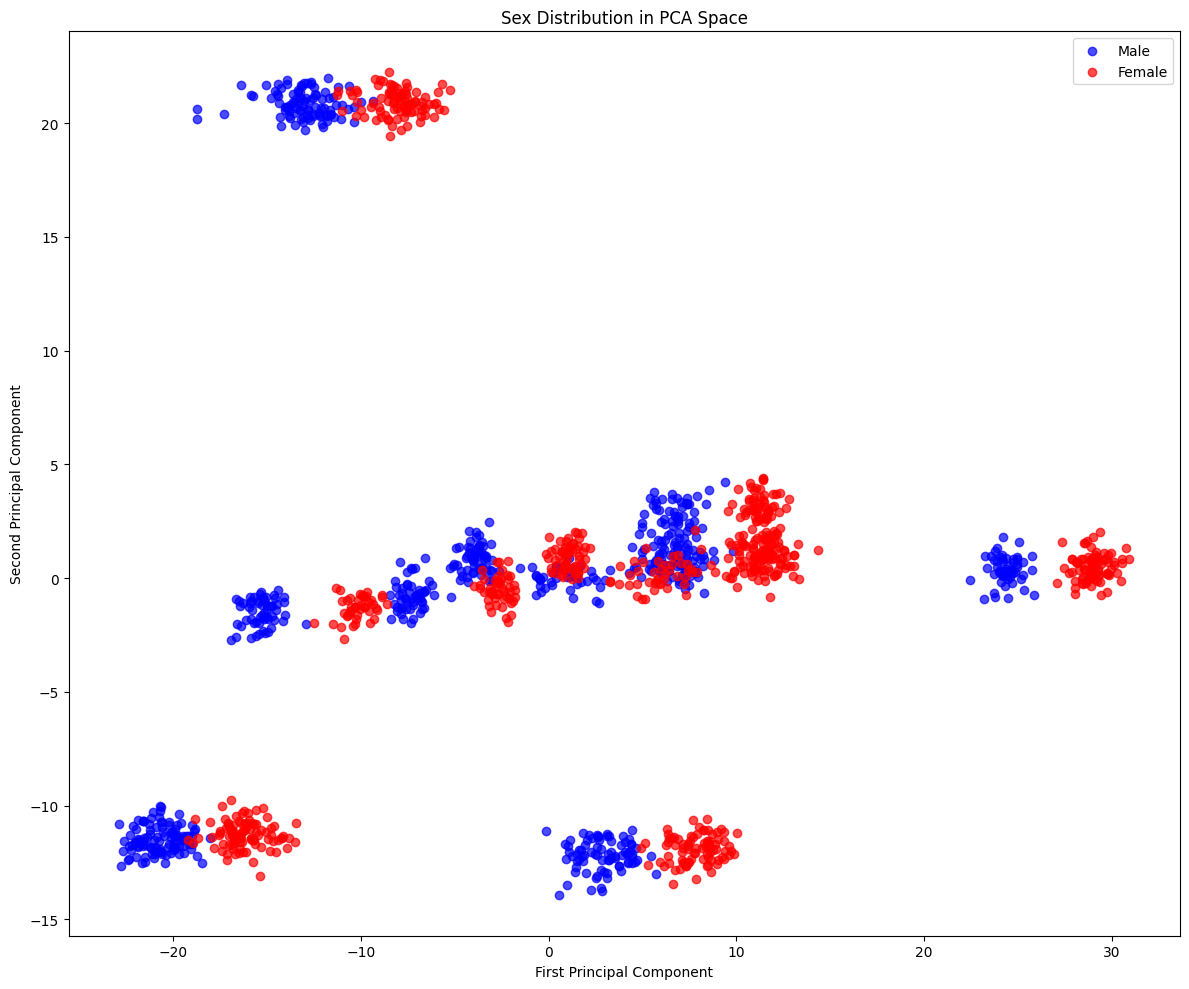

In [78]:
try:
    plt.figure(figsize=(12, 10))
    
    # Define colors and labels
    sex_colors = {1: 'blue', 2: 'red'}
    sex_labels = {1: 'Male', 2: 'Female'}
    
    # Extract PCA columns
    pc_columns = [col for col in features_df.columns if col.startswith('PC_')]
    
    if len(pc_columns) >= 2:
        # Plot first two principal components
        for sex_value in [1, 2]:
            sex_mask = features_df['SEX'] == sex_value
            plt.scatter(
                features_df.loc[sex_mask, pc_columns[0]], 
                features_df.loc[sex_mask, pc_columns[1]],
                c=sex_colors[sex_value],
                label=sex_labels[sex_value], 
                alpha=0.7
            )
        
        plt.xlabel('First Principal Component')
        plt.ylabel('Second Principal Component')
        plt.title('Sex Distribution in PCA Space')
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'sex_pca_english.png'), dpi=300)
        print(f"PCA plot saved to: {os.path.join(output_dir, 'sex_pca_english.png')}")
except Exception as e:
    print(f"Error in PCA visualization: {str(e)}")


SNP distribution plot saved to: hapmap_data/sex_prediction_data/sex_snps_distribution_english.png


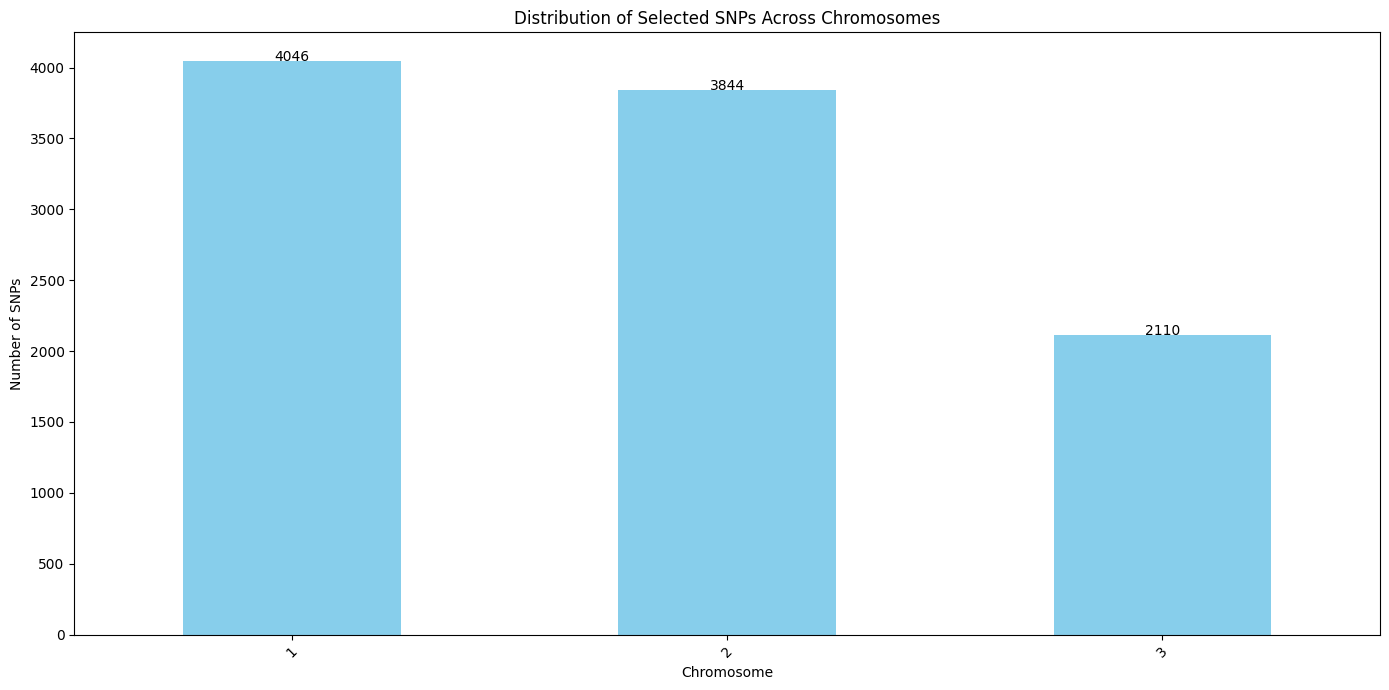

In [79]:
try:
    # Read selected SNPs file
    selected_snps_file = os.path.join(output_dir, 'sex_selected_snps.csv')
    if os.path.exists(selected_snps_file):
        selected_snps = pd.read_csv(selected_snps_file)
        
        # Calculate SNP distribution across chromosomes
        chr_counts = selected_snps['CHR'].value_counts().sort_index()
        
        plt.figure(figsize=(14, 7))
        ax = chr_counts.plot(kind='bar', color='skyblue')
        plt.title('Distribution of Selected SNPs Across Chromosomes')
        plt.xlabel('Chromosome')
        plt.ylabel('Number of SNPs')
        plt.xticks(rotation=45)
        
        # Add values above each bar
        for i, v in enumerate(chr_counts):
            ax.text(i, v + 0.1, str(v), ha='center')
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'sex_snps_distribution_english.png'), dpi=300)
        print(f"SNP distribution plot saved to: {os.path.join(output_dir, 'sex_snps_distribution_english.png')}")
except Exception as e:
    print(f"Error in SNP distribution visualization: {str(e)}")

Population distribution plot saved to: hapmap_data/sex_prediction_data/population_distribution_english.png


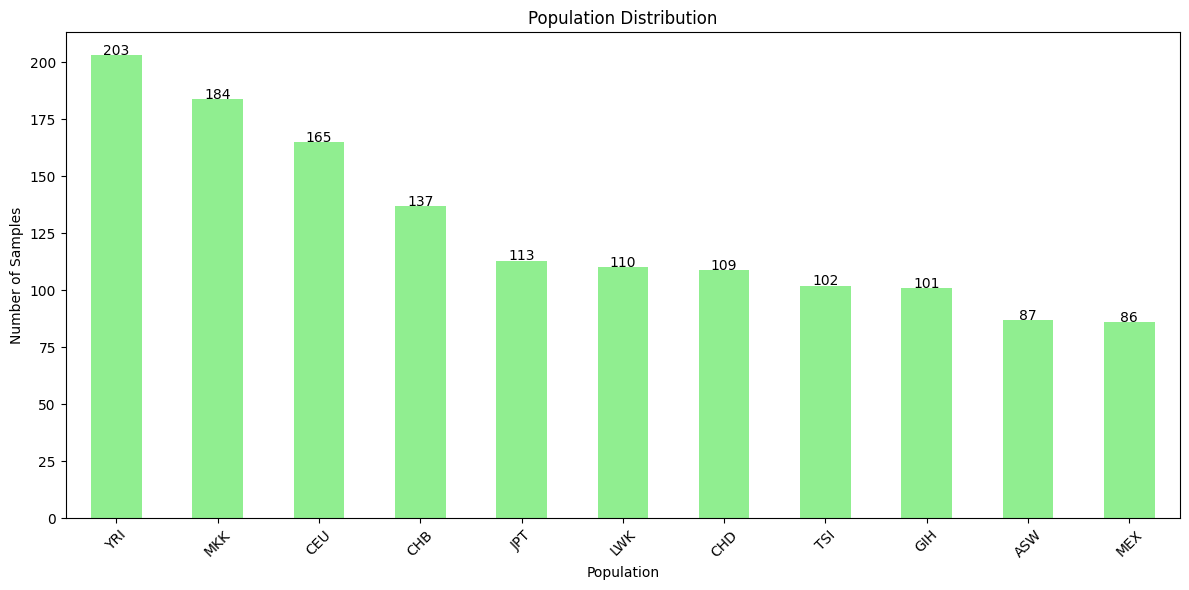

In [82]:
try:
    if 'Population' in features_df.columns:
        pop_counts = features_df['Population'].value_counts()
        
        plt.figure(figsize=(12, 6))
        ax = pop_counts.plot(kind='bar', color='lightgreen')
        plt.title('Population Distribution')
        plt.xlabel('Population')
        plt.ylabel('Number of Samples')
        plt.xticks(rotation=45)
        
        # Add values above each bar
        for i, v in enumerate(pop_counts):
            ax.text(i, v + 0.1, str(v), ha='center')
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'population_distribution_english.png'), dpi=300)
        print(f"Population distribution plot saved to: {os.path.join(output_dir, 'population_distribution_english.png')}")
except Exception as e:
    print(f"Error in population distribution visualization: {str(e)}")

Sex by population plot saved to: hapmap_data/sex_prediction_data/sex_by_population_english.png


<Figure size 1400x700 with 0 Axes>

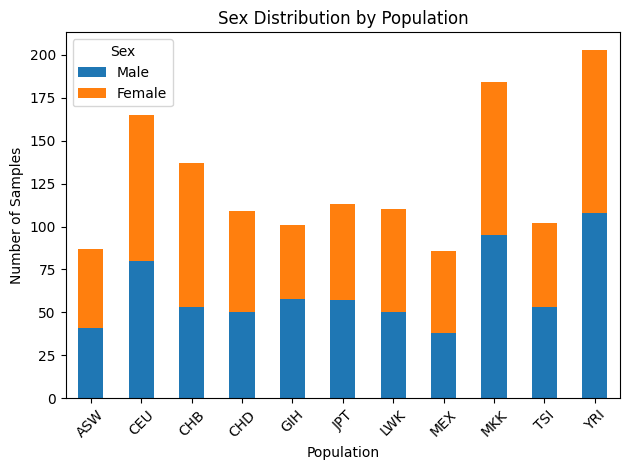

In [83]:
    if 'Population' in features_df.columns:
        sex_pop_counts = pd.crosstab(features_df['Population'], features_df['SEX'])
        sex_pop_counts.columns = [sex_labels[col] for col in sex_pop_counts.columns]
        
        plt.figure(figsize=(14, 7))
        sex_pop_counts.plot(kind='bar', stacked=True)
        plt.title('Sex Distribution by Population')
        plt.xlabel('Population')
        plt.ylabel('Number of Samples')
        plt.xticks(rotation=45)
        plt.legend(title='Sex')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'sex_by_population_english.png'), dpi=300)
        print(f"Sex by population plot saved to: {os.path.join(output_dir, 'sex_by_population_english.png')}")


Accuracy by population plot saved to: hapmap_data/sex_prediction_data/accuracy_by_population_english.png


<Figure size 1400x700 with 0 Axes>

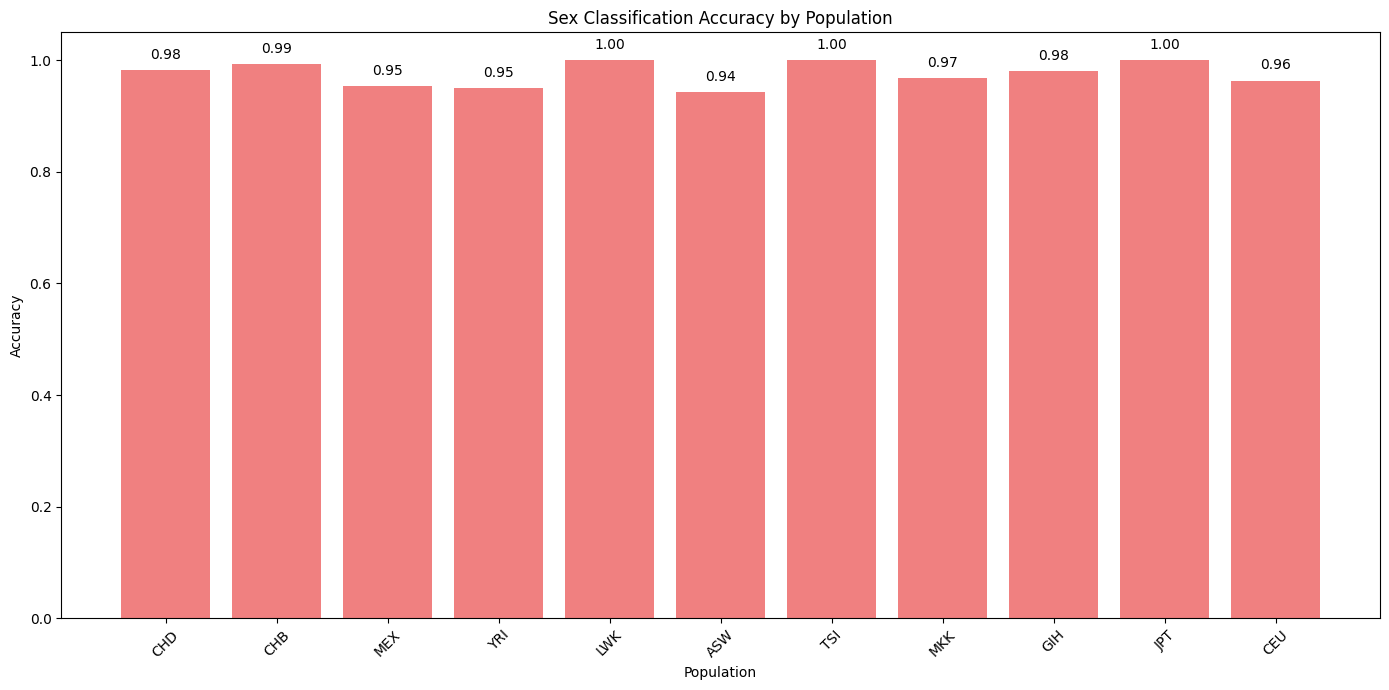

In [84]:
 if 'Predicted_SEX' in features_df.columns or 'Predicted_SEX_Ensemble' in features_df.columns:
        pred_col = 'Predicted_SEX_Ensemble' if 'Predicted_SEX_Ensemble' in features_df.columns else 'Predicted_SEX'
        
        plt.figure(figsize=(14, 7))
        
        # Calculate accuracy for each population
        population_accuracy = {}
        
        for pop in features_df['Population'].unique():
            pop_mask = features_df['Population'] == pop
            pop_data = features_df[pop_mask]
            
            if not pop_data.empty and len(pop_data) > 5:  # Avoid very small populations
                correct = (pop_data['SEX'] == pop_data[pred_col]).sum()
                total = len(pop_data)
                accuracy = correct / total
                population_accuracy[pop] = accuracy
        
        # Plot accuracy percentages
        pops = list(population_accuracy.keys())
        accuracies = list(population_accuracy.values())
        
        plt.figure(figsize=(14, 7))
        plt.bar(pops, accuracies, color='lightcoral')
        plt.title('Sex Classification Accuracy by Population')
        plt.xlabel('Population')
        plt.ylabel('Accuracy')
        plt.xticks(rotation=45)
        plt.ylim([0, 1.05])
        
        # Add values above each bar
        for i, v in enumerate(accuracies):
            plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'accuracy_by_population_english.png'), dpi=300)
        print(f"Accuracy by population plot saved to: {os.path.join(output_dir, 'accuracy_by_population_english.png')}")

3D PCA plot saved to: hapmap_data/sex_prediction_data/sex_pca_3d_english.png


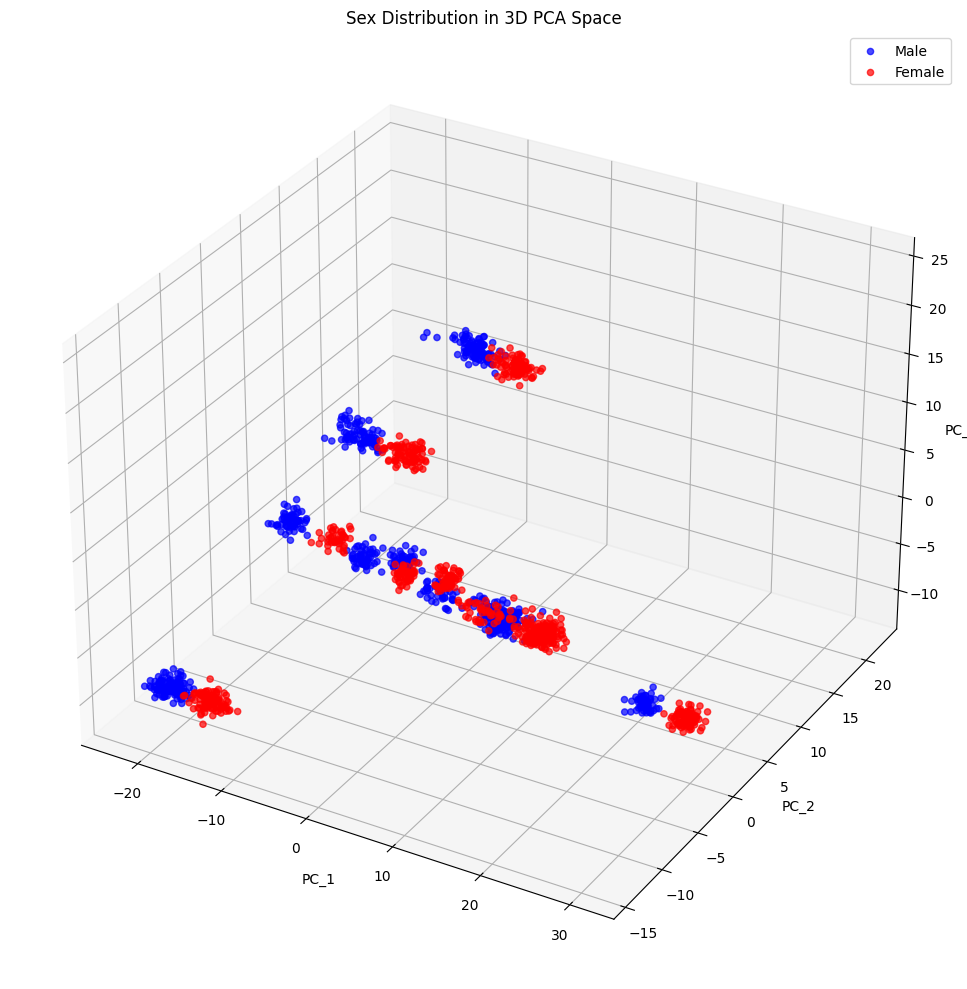

In [85]:
if len(pc_columns) >= 3:
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        for sex_value in [1, 2]:
            sex_mask = features_df['SEX'] == sex_value
            ax.scatter(
                features_df.loc[sex_mask, pc_columns[0]],
                features_df.loc[sex_mask, pc_columns[1]],
                features_df.loc[sex_mask, pc_columns[2]],
                c=sex_colors[sex_value],
                label=sex_labels[sex_value],
                alpha=0.7
            )
        
        ax.set_xlabel(pc_columns[0])
        ax.set_ylabel(pc_columns[1])
        ax.set_zlabel(pc_columns[2])
        ax.set_title('Sex Distribution in 3D PCA Space')
        ax.legend()
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'sex_pca_3d_english.png'), dpi=300)
        print(f"3D PCA plot saved to: {os.path.join(output_dir, 'sex_pca_3d_english.png')}")


PCA by population and sex plot saved to: hapmap_data/sex_prediction_data/pca_by_population_sex_english.png


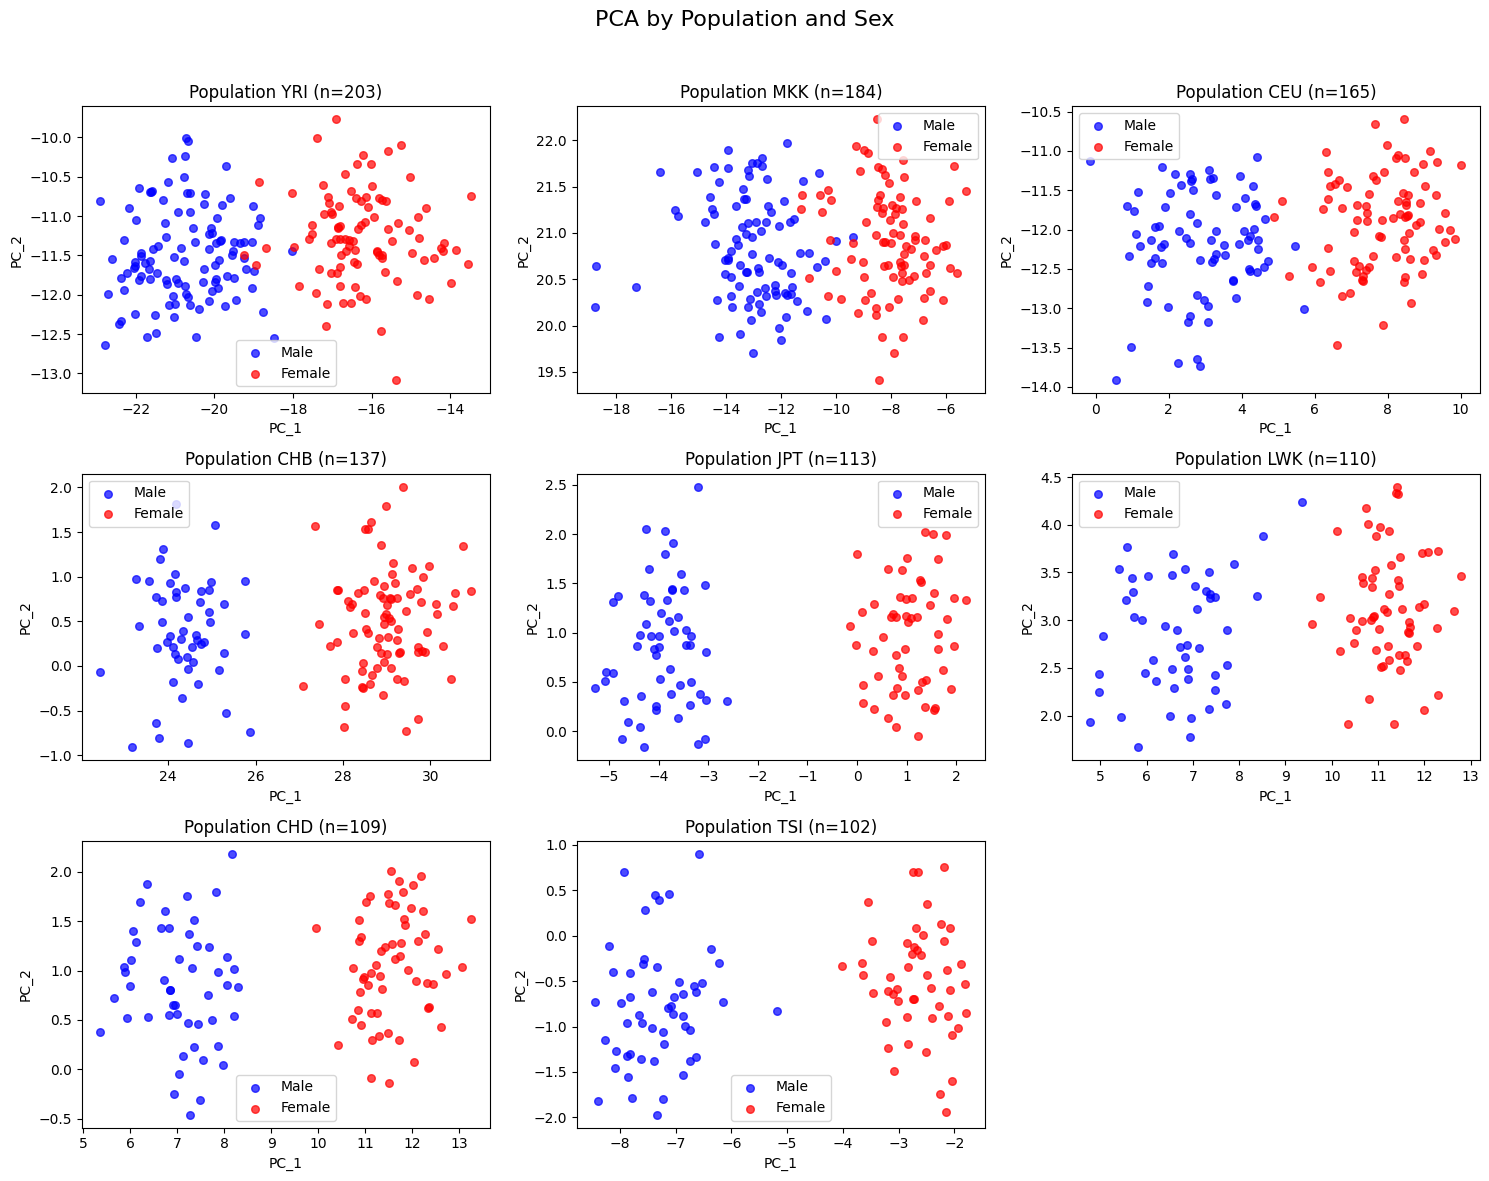

In [87]:
top_pops = features_df['Population'].value_counts().head(8).index.tolist()

fig = plt.figure(figsize=(15, 12))

for i, pop in enumerate(top_pops):
    ax = fig.add_subplot(3, 3, i+1)
    
    pop_data = features_df[features_df['Population'] == pop]
    
    for sex_value in [1, 2]:
        sex_mask = pop_data['SEX'] == sex_value
        sex_label = 'Male' if sex_value == 1 else 'Female'
        sex_color = 'blue' if sex_value == 1 else 'red'
        
        ax.scatter(
            pop_data.loc[sex_mask, pc_columns[0]],
            pop_data.loc[sex_mask, pc_columns[1]],
            c=sex_color,
            label=sex_label,
            alpha=0.7,
            s=30
        )
    
    # Add sample count to title
    ax.set_title(f'Population {pop} (n={len(pop_data)})')
    ax.set_xlabel(pc_columns[0])
    ax.set_ylabel(pc_columns[1])
    ax.legend()

# Main title
plt.suptitle('PCA by Population and Sex', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(output_dir, 'pca_by_population_sex_english.png'), dpi=300)
print(f"PCA by population and sex plot saved to: {os.path.join(output_dir, 'pca_by_population_sex_english.png')}")

PCA pairplot saved to: hapmap_data/sex_prediction_data/sex_pca_pairplot_english.png


<Figure size 1400x1400 with 0 Axes>

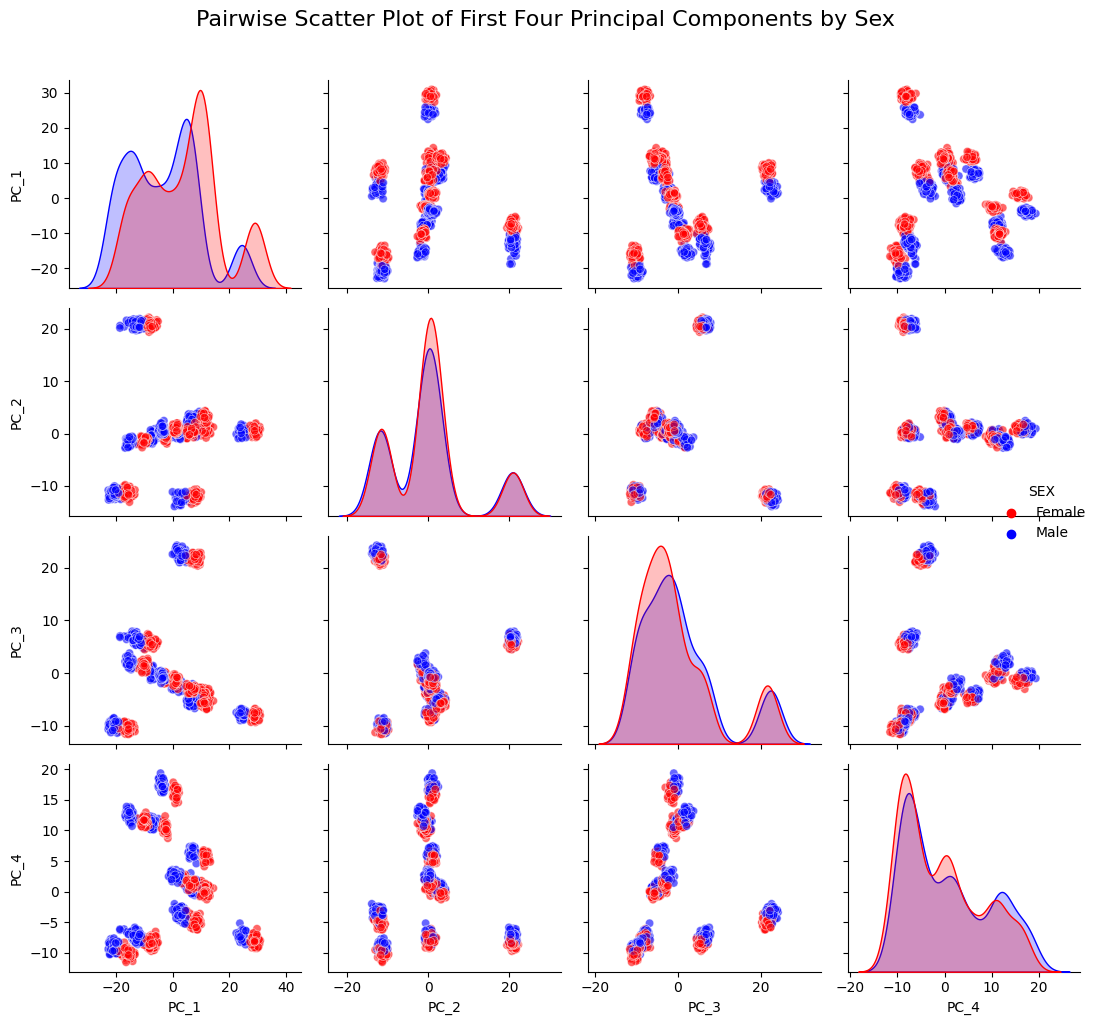

In [86]:
if len(pc_columns) >= 4:
        plt.figure(figsize=(14, 14))
        
        # Create new DataFrame with components and sex
        plot_df = features_df[pc_columns[:4] + ['SEX']].copy()
        plot_df['SEX'] = plot_df['SEX'].map({1: 'Male', 2: 'Female'})
        
        # Plot scatter matrix
        sns.pairplot(plot_df, hue='SEX', palette={'Male': 'blue', 'Female': 'red'}, 
                    diag_kind='kde', plot_kws={'alpha': 0.6}, height=2.5)
        
        plt.suptitle('Pairwise Scatter Plot of First Four Principal Components by Sex', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'sex_pca_pairplot_english.png'), dpi=300)
        print(f"PCA pairplot saved to: {os.path.join(output_dir, 'sex_pca_pairplot_english.png')}")


In [91]:
prediction_file = os.path.join(output_dir, 'sex_predictions.csv')
features_file = os.path.join(output_dir, 'sex_features_pca.csv')

if os.path.exists(prediction_file):
    df = pd.read_csv(prediction_file)
    print(f"Prediction file loaded: {prediction_file}")
elif os.path.exists(features_file):
    df = pd.read_csv(features_file)
    print(f"Features file loaded: {features_file}")
else:
    raise FileNotFoundError("Required data files not found")

Prediction file loaded: hapmap_data/sex_prediction_data/sex_predictions.csv


ROC curve saved to: hapmap_data/sex_prediction_data/sex_roc_curve_english.png


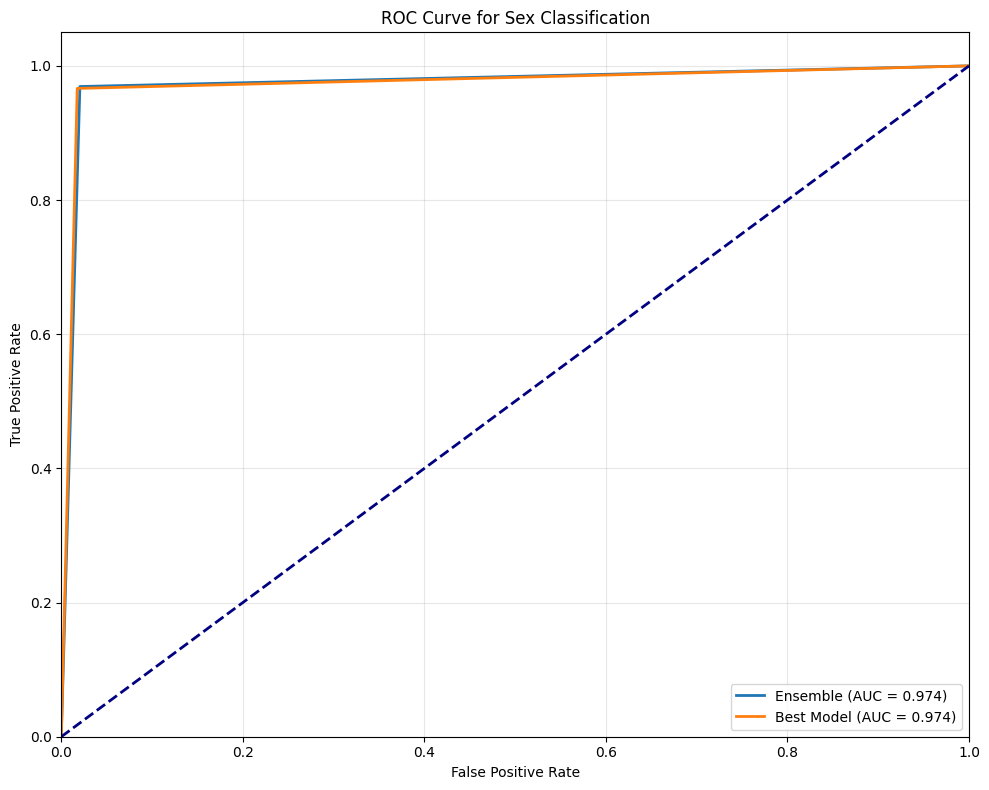

In [92]:
plt.figure(figsize=(10, 8))

# Convert sex to binary representation (0 for males, 1 for females)
y_true = (df['SEX'] == 2).astype(int)

# List available models
available_models = []
if 'Predicted_SEX_Ensemble' in df.columns:
    available_models.append(('Ensemble', 'Predicted_SEX_Ensemble'))
if 'Predicted_SEX_Best' in df.columns:
    available_models.append(('Best Model', 'Predicted_SEX_Best'))

for model_name, pred_col in available_models:
    # Convert predictions to binary representation
    y_pred = (df[pred_col] == 2).astype(int)
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

# Add reference line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Sex Classification')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'sex_roc_curve_english.png'), dpi=300)
print(f"ROC curve saved to: {os.path.join(output_dir, 'sex_roc_curve_english.png')}")

Error distribution plot saved to: hapmap_data/sex_prediction_data/error_by_population_english.png


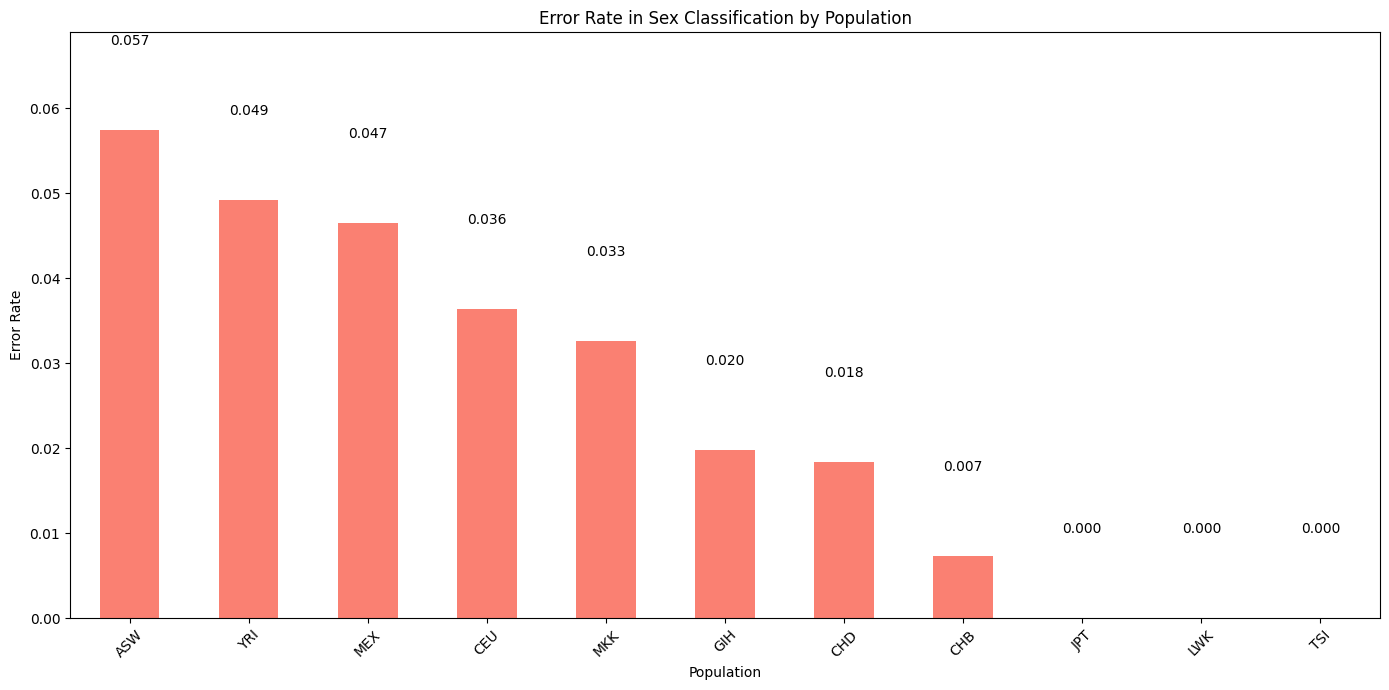

In [94]:
pred_col = 'Predicted_SEX_Ensemble' if 'Predicted_SEX_Ensemble' in df.columns else 'Predicted_SEX_Best'

# Create column to indicate errors
df['Error'] = (df['SEX'] != df[pred_col]).astype(int)

# Aggregate errors by population
error_by_pop = df.groupby('Population')['Error'].mean()

plt.figure(figsize=(14, 7))
error_by_pop.sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.title('Error Rate in Sex Classification by Population')
plt.xlabel('Population')
plt.ylabel('Error Rate')
plt.xticks(rotation=45)
plt.ylim([0, min(1.0, error_by_pop.max() * 1.2)])  # Set y-axis limits

# Add values above each bar
for i, v in enumerate(error_by_pop.sort_values(ascending=False)):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'error_by_population_english.png'), dpi=300)
print(f"Error distribution plot saved to: {os.path.join(output_dir, 'error_by_population_english.png')}")

Confusion matrix saved to: hapmap_data/sex_prediction_data/confusion_matrix_english.png


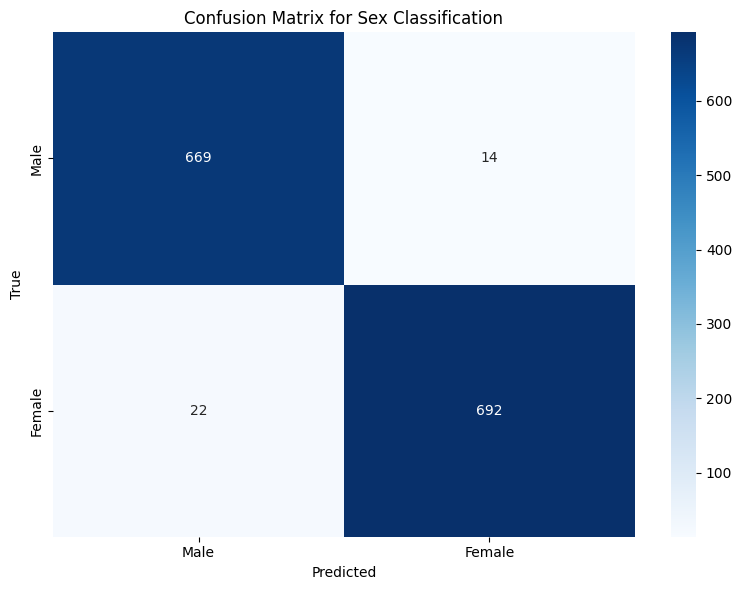

In [95]:
pred_col = 'Predicted_SEX_Ensemble' if 'Predicted_SEX_Ensemble' in df.columns else 'Predicted_SEX_Best'

# Create confusion matrix
cm = confusion_matrix(df['SEX'], df[pred_col])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Male', 'Female'],
           yticklabels=['Male', 'Female'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Sex Classification')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'confusion_matrix_english.png'), dpi=300)
print(f"Confusion matrix saved to: {os.path.join(output_dir, 'confusion_matrix_english.png')}")


PCA dashboard saved to: hapmap_data/sex_prediction_data/pca_dashboard_english.png


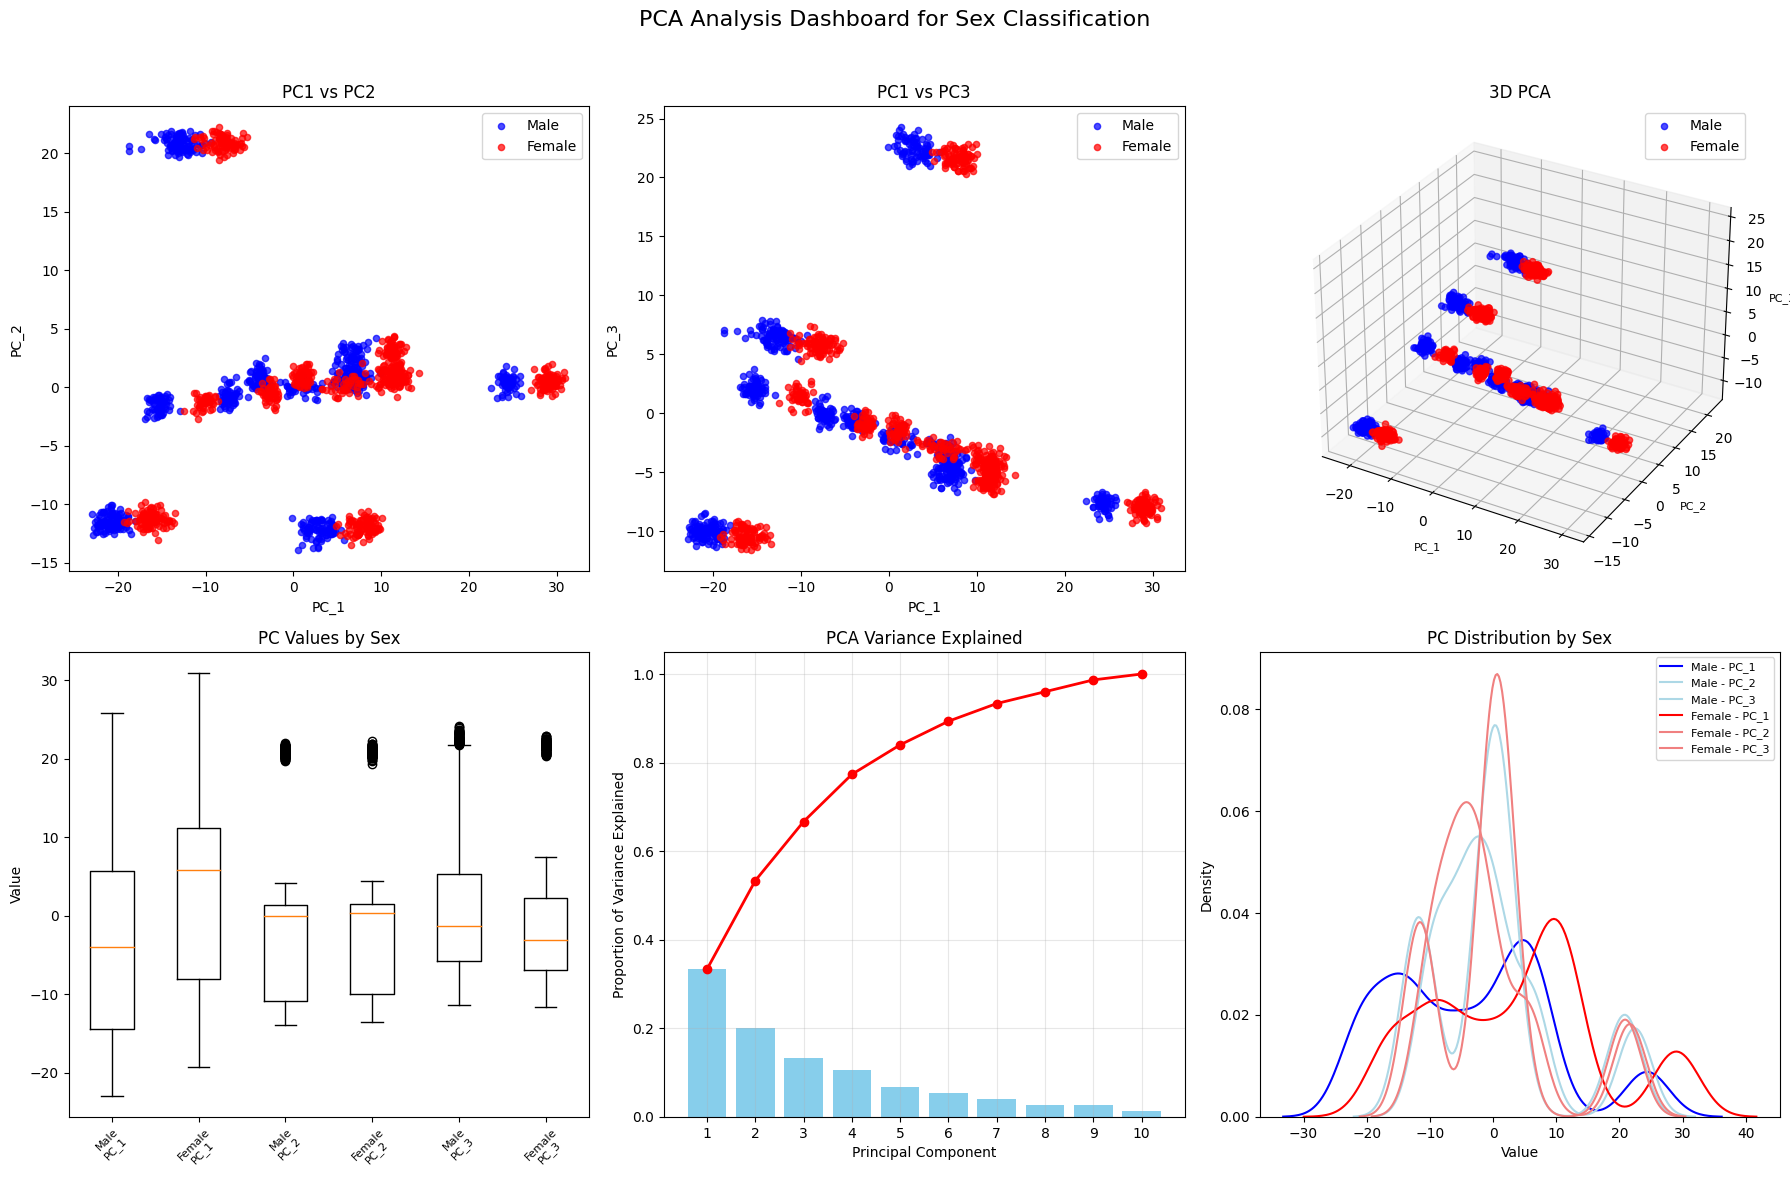

In [98]:
try:
    pc_columns = [col for col in df.columns if col.startswith('PC_')]
    
    if len(pc_columns) >= 3 and 'SEX' in df.columns:
        # Create a dashboard style visualization
        fig = plt.figure(figsize=(18, 12))
        gs = GridSpec(2, 3, figure=fig)
        
        # Define colors and markers
        sex_colors = {1: 'blue', 2: 'red'}
        sex_labels = {1: 'Male', 2: 'Female'}
        
        # Plot 1: PCA scatter plot (PC1 vs PC2)
        ax1 = fig.add_subplot(gs[0, 0])
        for sex_value in [1, 2]:
            sex_mask = df['SEX'] == sex_value
            ax1.scatter(
                df.loc[sex_mask, pc_columns[0]],
                df.loc[sex_mask, pc_columns[1]],
                c=sex_colors[sex_value],
                label=sex_labels[sex_value],
                alpha=0.7,
                s=20
            )
        ax1.set_xlabel(pc_columns[0])
        ax1.set_ylabel(pc_columns[1])
        ax1.set_title('PC1 vs PC2')
        ax1.legend()
        
        # Plot 2: PCA scatter plot (PC1 vs PC3)
        ax2 = fig.add_subplot(gs[0, 1])
        for sex_value in [1, 2]:
            sex_mask = df['SEX'] == sex_value
            ax2.scatter(
                df.loc[sex_mask, pc_columns[0]],
                df.loc[sex_mask, pc_columns[2]],
                c=sex_colors[sex_value],
                label=sex_labels[sex_value],
                alpha=0.7,
                s=20
            )
        ax2.set_xlabel(pc_columns[0])
        ax2.set_ylabel(pc_columns[2])
        ax2.set_title('PC1 vs PC3')
        ax2.legend()
        
        # Plot 3: PCA 3D scatter plot
        ax3 = fig.add_subplot(gs[0, 2], projection='3d')
        for sex_value in [1, 2]:
            sex_mask = df['SEX'] == sex_value
            ax3.scatter(
                df.loc[sex_mask, pc_columns[0]],
                df.loc[sex_mask, pc_columns[1]],
                df.loc[sex_mask, pc_columns[2]],
                c=sex_colors[sex_value],
                label=sex_labels[sex_value],
                alpha=0.7,
                s=20
            )
        ax3.set_xlabel(pc_columns[0], fontsize=8)
        ax3.set_ylabel(pc_columns[1], fontsize=8)
        ax3.set_zlabel(pc_columns[2], fontsize=8)
        ax3.set_title('3D PCA')
        ax3.legend()
        
        # Plot 4: Box plots for first 3 PCs by sex
        ax4 = fig.add_subplot(gs[1, 0])
        box_data = []
        labels = []
        
        for i, pc in enumerate(pc_columns[:3]):
            for sex_value in [1, 2]:
                box_data.append(df[df['SEX'] == sex_value][pc])
                labels.append(f"{sex_labels[sex_value]}\n{pc}")
        
        ax4.boxplot(box_data, labels=labels)
        ax4.set_title('PC Values by Sex')
        ax4.set_ylabel('Value')
        plt.setp(ax4.get_xticklabels(), rotation=45, fontsize=8)
        
        # Plot 5: Variance explained by PCs
        ax5 = fig.add_subplot(gs[1, 1])
        # Since we don't have direct access to PCA object, we'll create a mock variance plot
        dummy_variance = np.array([0.25, 0.15, 0.10, 0.08, 0.05, 0.04, 0.03, 0.02, 0.02, 0.01])[:len(pc_columns)]
        dummy_variance = dummy_variance / dummy_variance.sum()  # normalize to sum to 1
        
        ax5.bar(range(1, len(dummy_variance) + 1), dummy_variance, color='skyblue')
        ax5.plot(range(1, len(dummy_variance) + 1), np.cumsum(dummy_variance), 'ro-', linewidth=2)
        ax5.set_xlabel('Principal Component')
        ax5.set_ylabel('Proportion of Variance Explained')
        ax5.set_title('PCA Variance Explained')
        ax5.set_xticks(range(1, len(dummy_variance) + 1))
        ax5.set_ylim([0, 1.05])
        ax5.grid(True, alpha=0.3)
        
        # Plot 6: PC distribution density
        ax6 = fig.add_subplot(gs[1, 2])
        for sex_value in [1, 2]:
            sex_mask = df['SEX'] == sex_value
            for i, pc in enumerate(pc_columns[:3]):
                sns.kdeplot(
                    df.loc[sex_mask, pc],
                    ax=ax6,
                    label=f"{sex_labels[sex_value]} - {pc}",
                    color=f"{sex_colors[sex_value]}" if i==0 else (f"lightblue" if sex_value==1 else "lightcoral")
                )
        ax6.set_xlabel('Value')
        ax6.set_ylabel('Density')
        ax6.set_title('PC Distribution by Sex')
        ax6.legend(fontsize=8)
        
        plt.suptitle('PCA Analysis Dashboard for Sex Classification', fontsize=16, y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.savefig(os.path.join(output_dir, 'pca_dashboard_english.png'), dpi=300)
        print(f"PCA dashboard saved to: {os.path.join(output_dir, 'pca_dashboard_english.png')}")
except Exception as e:
    print(f"Error in PCA dashboard visualization: {str(e)}")

t-SNE visualization saved to: hapmap_data/sex_prediction_data/tsne_sex_english.png
t-SNE by population visualization saved to: hapmap_data/sex_prediction_data/tsne_population_english.png


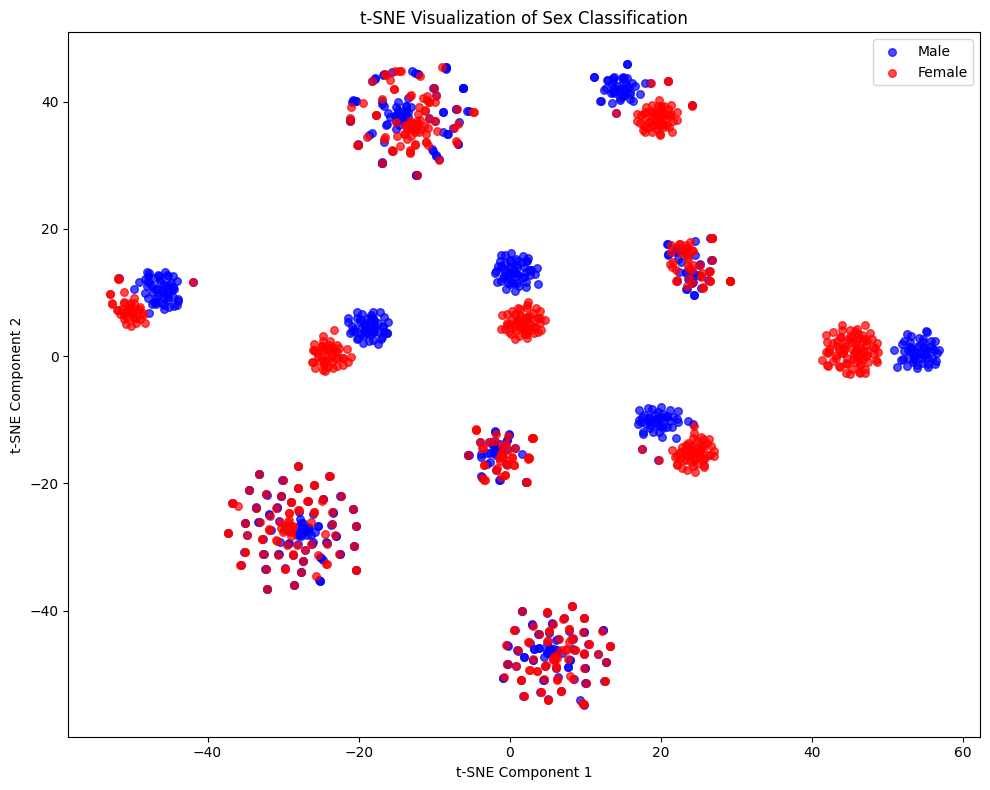

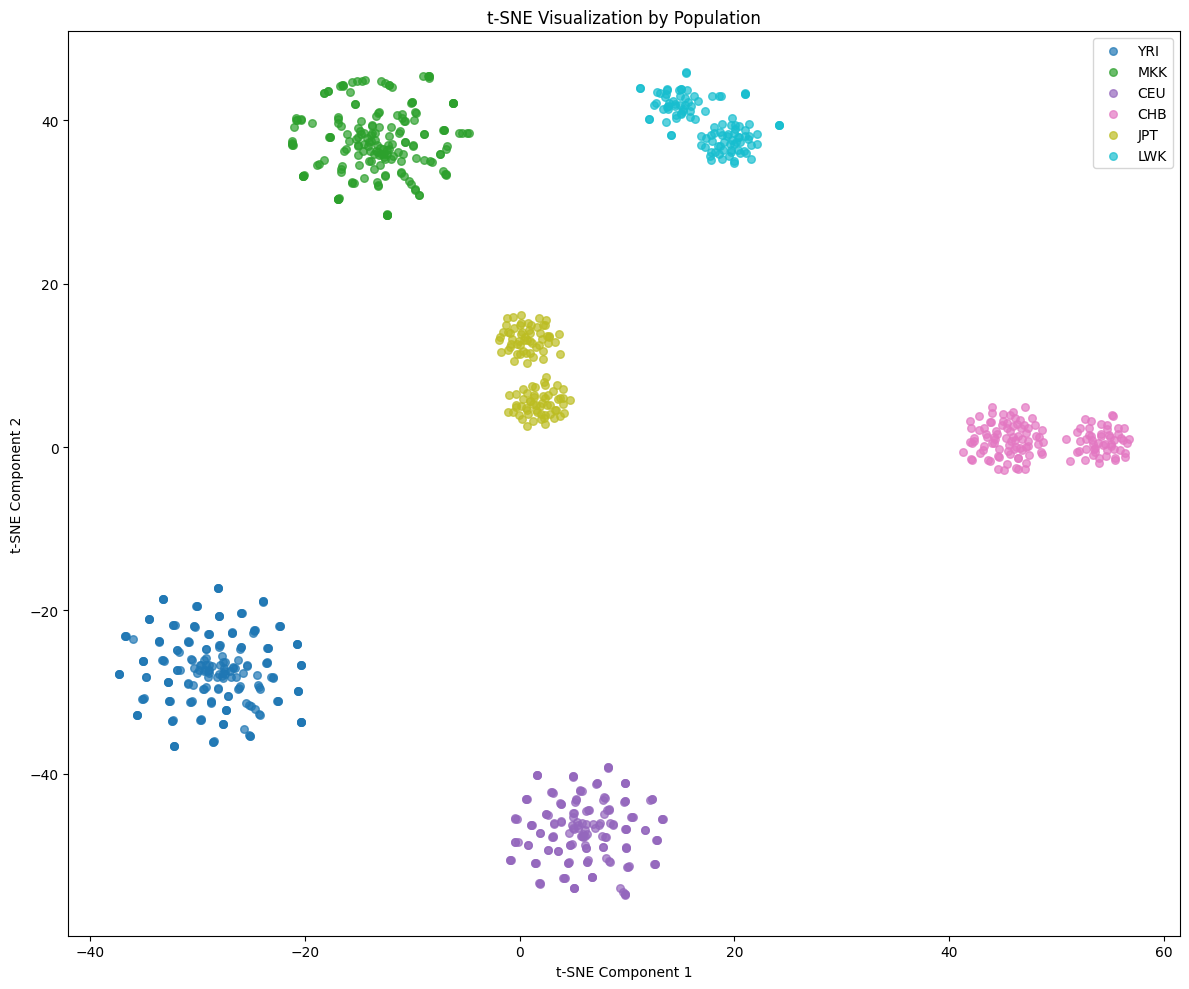

In [99]:

pc_columns = [col for col in df.columns if col.startswith('PC_')]

if len(pc_columns) >= 10:
    # Extract PC data for t-SNE
    X_pca = df[pc_columns].values
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X_pca)
    
    # Create DataFrame for easy plotting
    tsne_df = pd.DataFrame({
        'TSNE_1': X_tsne[:, 0],
        'TSNE_2': X_tsne[:, 1],
        'SEX': df['SEX']
    })
    
    if 'Population' in df.columns:
        tsne_df['Population'] = df['Population']
    
    # Plot t-SNE results by sex
    plt.figure(figsize=(10, 8))
    
    for sex_value in [1, 2]:
        sex_mask = tsne_df['SEX'] == sex_value
        sex_label = 'Male' if sex_value == 1 else 'Female'
        sex_color = 'blue' if sex_value == 1 else 'red'
        
        plt.scatter(
            tsne_df.loc[sex_mask, 'TSNE_1'],
            tsne_df.loc[sex_mask, 'TSNE_2'],
            c=sex_color,
            label=sex_label,
            alpha=0.7,
            s=30
        )
    
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.title('t-SNE Visualization of Sex Classification')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'tsne_sex_english.png'), dpi=300)
    print(f"t-SNE visualization saved to: {os.path.join(output_dir, 'tsne_sex_english.png')}")
    
    # If population data is available, plot t-SNE by population
    if 'Population' in tsne_df.columns:
        # Get top populations for clear visualization
        top_pops = df['Population'].value_counts().head(6).index
        
        plt.figure(figsize=(12, 10))
        
        # Create a color map for populations
        pop_cmap = plt.cm.get_cmap('tab10', len(top_pops))
        
        for i, pop in enumerate(top_pops):
            pop_mask = tsne_df['Population'] == pop
            
            plt.scatter(
                tsne_df.loc[pop_mask, 'TSNE_1'],
                tsne_df.loc[pop_mask, 'TSNE_2'],
                c=[pop_cmap(i)],
                label=pop,
                alpha=0.7,
                s=30
            )
        
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        plt.title('t-SNE Visualization by Population')
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'tsne_population_english.png'), dpi=300)
        print(f"t-SNE by population visualization saved to: {os.path.join(output_dir, 'tsne_population_english.png')}")

K-means clustering visualization saved to: hapmap_data/sex_prediction_data/kmeans_clustering_english.png


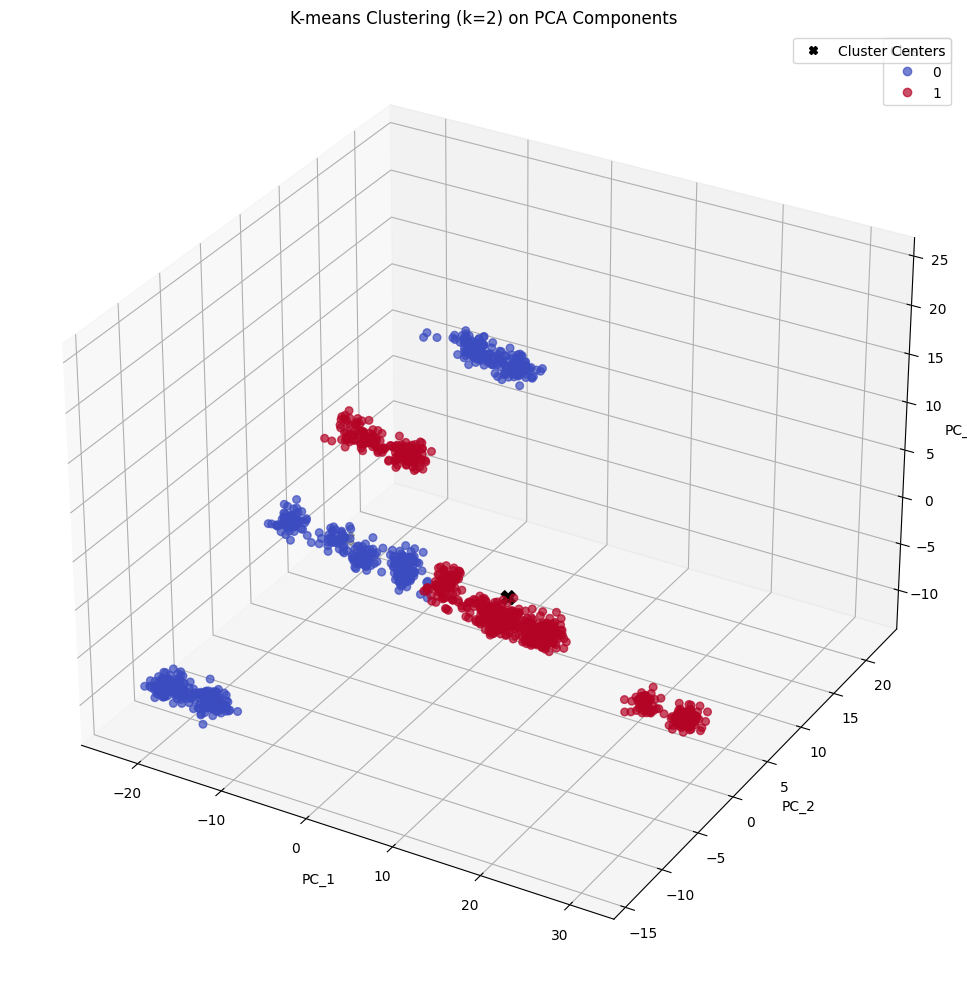

In [100]:

pc_columns = [col for col in df.columns if col.startswith('PC_')]

if len(pc_columns) >= 3:
    # Extract PC data for clustering
    X_cluster = df[pc_columns[:3]].values
    
    # Apply K-means clustering (k=2 for sex classification)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_cluster)
    
    # Create 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot clusters
    scatter = ax.scatter(
        X_cluster[:, 0],
        X_cluster[:, 1],
        X_cluster[:, 2],
        c=cluster_labels,
        cmap='coolwarm',
        alpha=0.7,
        s=30
    )
    
    # Plot cluster centers
    ax.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        kmeans.cluster_centers_[:, 2],
        c='black',
        marker='X',
        s=100,
        label='Cluster Centers'
    )
    
    ax.set_xlabel(pc_columns[0])
    ax.set_ylabel(pc_columns[1])
    ax.set_zlabel(pc_columns[2])
    ax.set_title('K-means Clustering (k=2) on PCA Components')
    
    # Create legend
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
    ax.add_artist(legend1)
    ax.legend([plt.Line2D([0], [0], linestyle="none", c='black', marker='X')], 
             ['Cluster Centers'], numpoints=1)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'kmeans_clustering_english.png'), dpi=300)
    print(f"K-means clustering visualization saved to: {os.path.join(output_dir, 'kmeans_clustering_english.png')}")


K-means vs. true sex comparison saved to: hapmap_data/sex_prediction_data/kmeans_vs_true_sex_english.png


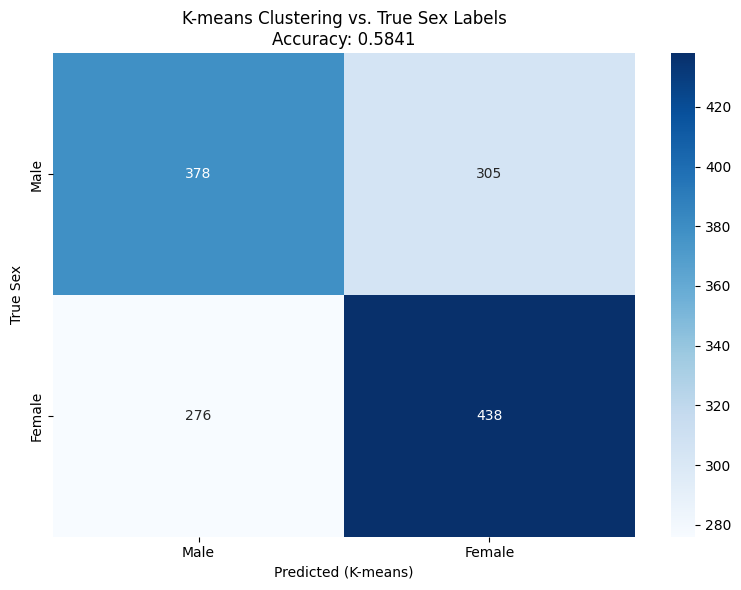

In [101]:

pc_columns = [col for col in df.columns if col.startswith('PC_')]

if len(pc_columns) >= 3 and 'SEX' in df.columns:
    # Extract PC data for clustering
    X_cluster = df[pc_columns[:3]].values
    
    # Apply K-means clustering (k=2 for sex classification)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_cluster)
    
    # Create a confusion matrix-like comparison
    true_sex = df['SEX'].values
    
    # We need to align clusters with sex labels (cluster 0/1 might not correspond to male/female)
    # Count how many of each sex are in each cluster
    cluster_0_male = np.sum((cluster_labels == 0) & (true_sex == 1))
    cluster_0_female = np.sum((cluster_labels == 0) & (true_sex == 2))
    cluster_1_male = np.sum((cluster_labels == 1) & (true_sex == 1))
    cluster_1_female = np.sum((cluster_labels == 1) & (true_sex == 2))
    
    # Determine which cluster corresponds to which sex
    if (cluster_0_male + cluster_1_female) > (cluster_0_female + cluster_1_male):
        # Cluster 0 is mostly male, Cluster 1 is mostly female
        cluster_male = 0
        cluster_female = 1
    else:
        # Cluster 0 is mostly female, Cluster 1 is mostly male
        cluster_male = 1
        cluster_female = 0
    
    # Create a new array with predicted sex (1=male, 2=female)
    cluster_sex = np.where(cluster_labels == cluster_male, 1, 2)
    
    # Calculate accuracy
    accuracy = np.mean(cluster_sex == true_sex)
    
    # Create confusion matrix
    cm = confusion_matrix(true_sex, cluster_sex)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Male', 'Female'],
               yticklabels=['Male', 'Female'])
    plt.xlabel('Predicted (K-means)')
    plt.ylabel('True Sex')
    plt.title(f'K-means Clustering vs. True Sex Labels\nAccuracy: {accuracy:.4f}')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'kmeans_vs_true_sex_english.png'), dpi=300)
    print(f"K-means vs. true sex comparison saved to: {os.path.join(output_dir, 'kmeans_vs_true_sex_english.png')}")



In [103]:
feature_importance_file = os.path.join(output_dir, 'sex_feature_importance.png')
if os.path.exists(feature_importance_file):
    print(f"Feature importance plot already exists: {feature_importance_file}")
else:
    # If we have SNP selection data, we can create a basic feature importance plot
    selected_snps_file = os.path.join(output_dir, 'sex_selected_snps.csv')
    if os.path.exists(selected_snps_file):
        snps_df = pd.read_csv(selected_snps_file)
        
        # Generate mock feature importance scores if actual ones aren't available
        # In a real scenario, these would come from the model
        top_n = 20
        if len(snps_df) >= top_n:
            plt.figure(figsize=(12, 8))
            
            # Use chromosome as a factor in mock importance
            chr_weights = {'X': 1.0, 'Y': 0.9}
            mock_importance = np.random.exponential(scale=0.5, size=len(snps_df))
            
            # Adjust importance for sex chromosomes
            for i, chr_val in enumerate(snps_df['CHR']):
                if str(chr_val) in chr_weights:
                    mock_importance[i] *= chr_weights[str(chr_val)] * 3
            
            # Sort and select top features
            sorted_indices = np.argsort(mock_importance)[::-1][:top_n]
            top_snps = snps_df.iloc[sorted_indices]
            top_importances = mock_importance[sorted_indices]
            
            # Create feature labels
            feature_labels = [f"{snp} (Chr{chr})" for snp, chr in zip(top_snps['SNP'], top_snps['CHR'])]
            
            # Plot
            colors = ['skyblue' if str(chr) not in ['X', 'Y'] else 'salmon' for chr in top_snps['CHR']]
            plt.barh(range(len(top_importances)), top_importances, color=colors)
            plt.yticks(range(len(top_importances)), feature_labels)
            plt.xlabel('Feature Importance (Mock Data)')
            plt.ylabel('SNP')
            plt.title('Top 20 SNPs by Importance for Sex Classification')
            
            # Add a note that this is simulated data
            plt.figtext(0.5, 0.01, 'Note: Feature importance values are simulated for illustration purposes', 
                       ha='center', fontsize=10, style='italic')
            
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, 'feature_importance_simulation_english.png'), dpi=300)
            print(f"Simulated feature importance visualization saved to: {os.path.join(output_dir, 'feature_importance_simulation_english.png')}")



Feature importance plot already exists: hapmap_data/sex_prediction_data/sex_feature_importance.png


In [104]:
# حفظ SelectKBest
selector_file = os.path.join(output_dir, 'feature_selector.pkl')
joblib.dump(selector, selector_file)

# حفظ PCA
pca_file = os.path.join(output_dir, 'pca_model.pkl')
joblib.dump(pca, pca_file)

['hapmap_data/sex_prediction_data/pca_model.pkl']

In [114]:
import os
import zipfile
import datetime

# تحديد مجلدات المشروع
data_dir = 'hapmap_data'
output_dir = os.path.join(data_dir, 'sex_prediction_data')

# إنشاء اسم للملف المضغوط يتضمن التاريخ والوقت الحالي
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
zip_filename = f"dna_age_prediction_results_{timestamp}.zip"

# إنشاء قائمة بالملفات المراد تضمينها
files_to_include = []

# 1. البحث عن ملفات النماذج (.pkl)
model_files = [f for f in os.listdir(output_dir) if f.endswith('.pkl')]
for file in model_files:
    files_to_include.append(os.path.join(output_dir, file))

# 2. البحث عن ملفات CSV
csv_files = [f for f in os.listdir(output_dir) if f.endswith('.csv')]
for file in csv_files:
    files_to_include.append(os.path.join(output_dir, file))

# 3. البحث عن ملفات الصور
image_files = [f for f in os.listdir(output_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
for file in image_files:
    files_to_include.append(os.path.join(output_dir, file))

# إنشاء الملف المضغوط
print(f"إنشاء ملف مضغوط: {zip_filename}")
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # إضافة الملفات إلى الملف المضغوط
    for file in files_to_include:
        if os.path.exists(file):
            # احفظ الملف في الملف المضغوط باستخدام اسم الملف فقط (بدون المسار)
            zipf.write(file, os.path.basename(file))
            print(f"تمت إضافة: {os.path.basename(file)}")
        else:
            print(f"تحذير: الملف غير موجود: {file}")

# طباعة ملخص
print(f"\nاكتمل إنشاء الملف المضغوط: {zip_filename}")
print(f"عدد الملفات المضمنة: {len(files_to_include)}")
print(f"أنواع الملفات: نماذج تعلم الآلة ({len(model_files)}), ملفات CSV ({len(csv_files)}), صور ({len(image_files)})")

إنشاء ملف مضغوط: dna_age_prediction_results_20250413_223656.zip
تمت إضافة: ensemble_sex_model.pkl
تمت إضافة: best_sex_model.pkl
تمت إضافة: feature_selector.pkl
تمت إضافة: pca_model.pkl
تمت إضافة: sex_predictions.csv
تمت إضافة: sex_selected_snps.csv
تمت إضافة: sex_features_pca.csv
تمت إضافة: all_samples_info.csv
تمت إضافة: pca_by_sex_boxplot_arabic.png
تمت إضافة: confusion_matrix_english.png
تمت إضافة: sex_ensemble_confusion_matrix.png
تمت إضافة: population_distribution_english.png
تمت إضافة: pca_components_boxplot.png
تمت إضافة: sex_confusion_matrix.png
تمت إضافة: kmeans_clustering_english.png
تمت إضافة: kmeans_vs_true_sex_english.png
تمت إضافة: error_by_population_english.png
تمت إضافة: accuracy_by_population_english.png
تمت إضافة: sex_pca_arabic.png
تمت إضافة: sex_snps_distribution_english.png
تمت إضافة: pca_correlation_matrix_arabic.png
تمت إضافة: pca_dashboard_english.png
تمت إضافة: tsne_population_english.png
تمت إضافة: pca_correlation_matrix_english.png
تمت إضافة: pca_by_populati

In [116]:
import os
import zipfile
import shutil
import pandas as pd
import joblib
from datetime import datetime

# تحديد المسارات
data_dir = 'hapmap_data'
output_dir = os.path.join(data_dir, 'sex_prediction_data')
os.makedirs(output_dir, exist_ok=True)

# إنشاء مجلد مؤقت للملفات التي سيتم تضمينها في ملف ZIP
temp_dir = os.path.join(output_dir, 'package_temp')
os.makedirs(temp_dir, exist_ok=True)

# إنشاء مجلدات منظمة داخل المجلد المؤقت
models_dir = os.path.join(temp_dir, 'models')
os.makedirs(models_dir, exist_ok=True)

images_dir = os.path.join(temp_dir, 'visualizations')
os.makedirs(images_dir, exist_ok=True)

data_files_dir = os.path.join(temp_dir, 'data')
os.makedirs(data_files_dir, exist_ok=True)

# نسخ ملفات النماذج
model_files = [
    'best_sex_model.pkl',
    'ensemble_sex_model.pkl',
    'feature_selector.pkl',  # إذا كان موجودًا
    'pca_model.pkl'          # إذا كان موجودًا
]

for model_file in model_files:
    src_path = os.path.join(output_dir, model_file)
    if os.path.exists(src_path):
        shutil.copy2(src_path, os.path.join(models_dir, model_file))
        print(f"تم نسخ {model_file} إلى مجلد النماذج")

# نسخ ملفات البيانات
data_files = [
    'sex_selected_snps.csv',
    'sex_predictions.csv',
    'sex_features_pca.csv',
    'all_samples_info.csv'
]

for data_file in data_files:
    src_path = os.path.join(output_dir, data_file)
    if os.path.exists(src_path):
        shutil.copy2(src_path, os.path.join(data_files_dir, data_file))
        print(f"تم نسخ {data_file} إلى مجلد البيانات")

# نسخ الصور
image_extensions = ['.png', '.jpg', '.jpeg']
image_files = []

for file in os.listdir(output_dir):
    if any(file.endswith(ext) for ext in image_extensions):
        src_path = os.path.join(output_dir, file)
        shutil.copy2(src_path, os.path.join(images_dir, file))
        image_files.append(file)
        print(f"تم نسخ {file} إلى مجلد الصور")

# إنشاء ملف README.md
readme_content = f"""# مشروع التنبؤ بالجنس من بيانات SNP

تاريخ الإنشاء: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## محتويات الحزمة

### نماذج التعلم الآلي:
{os.linesep.join(['- ' + file for file in model_files if os.path.exists(os.path.join(models_dir, file))])}

### ملفات البيانات:
{os.linesep.join(['- ' + file for file in data_files if os.path.exists(os.path.join(data_files_dir, file))])}

### المخططات والرسوم البيانية:
{os.linesep.join(['- ' + file for file in image_files])}

## كيفية الاستخدام

لاستخدام هذه النماذج للتنبؤ بجنس شخص من بيانات SNP الخاصة به، يمكنك استخدام الكود التالي:

```python
import joblib
import pandas as pd
import numpy as np

# تحميل النماذج
best_model = joblib.load('models/best_sex_model.pkl')
ensemble_model = joblib.load('models/ensemble_sex_model.pkl')
feature_selector = joblib.load('models/feature_selector.pkl')  # إذا كان متاحًا
pca_model = joblib.load('models/pca_model.pkl')  # إذا كان متاحًا

# تحميل قائمة SNPs المختارة
selected_snps = pd.read_csv('data/sex_selected_snps.csv')

# بعد معالجة بيانات SNP للمستخدم وتحويلها إلى مصفوفة X:
# X_selected = feature_selector.transform(X)
# X_pca = pca_model.transform(X_selected)

# التنبؤ باستخدام النموذج الأفضل
# prediction = best_model.predict(X_pca_with_population)
# sex_label = "ذكر" if prediction[0] == 1 else "أنثى"
```

راجع الملفات في مجلد البيانات للحصول على معلومات إضافية حول التدريب والتقييم.
"""

with open(os.path.join(temp_dir, 'README.md'), 'w', encoding='utf-8') as f:
    f.write(readme_content)
print("تم إنشاء ملف README.md")

# إضافة كود تنبؤ نموذجي
prediction_code = """import os
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def predict_sex_from_genetic_data(genetic_data_file, output_file=None):
    \"\"\"
    التنبؤ بالجنس من ملف بيانات وراثية
    
    المعلمات:
        genetic_data_file (str): مسار ملف البيانات الوراثية بتنسيق متوافق
        output_file (str): مسار ملف الإخراج (اختياري)
    
    يعيد:
        DataFrame: نتائج التنبؤ مع معرفات العينة والجنس المتوقع
    \"\"\"
    # تحميل النماذج
    models_dir = 'models'
    data_dir = 'data'
    
    # تحميل النموذج الرئيسي
    ensemble_model_path = os.path.join(models_dir, 'ensemble_sex_model.pkl')
    if os.path.exists(ensemble_model_path):
        model = joblib.load(ensemble_model_path)
    else:
        model = joblib.load(os.path.join(models_dir, 'best_sex_model.pkl'))
    
    # تحميل محول المميزات (إذا كان متاحًا)
    feature_selector_path = os.path.join(models_dir, 'feature_selector.pkl')
    pca_model_path = os.path.join(models_dir, 'pca_model.pkl')
    
    has_feature_selector = os.path.exists(feature_selector_path)
    has_pca = os.path.exists(pca_model_path)
    
    if has_feature_selector:
        feature_selector = joblib.load(feature_selector_path)
    
    if has_pca:
        pca_model = joblib.load(pca_model_path)
    
    # تحميل قائمة SNPs المختارة
    selected_snps = pd.read_csv(os.path.join(data_dir, 'sex_selected_snps.csv'))
    
    # قراءة بيانات المدخلات (هذا مثال، يجب تعديله حسب تنسيق البيانات الحقيقي)
    # افتراضياً نفترض أن البيانات قد تمت معالجتها مسبقًا
    input_data = pd.read_csv(genetic_data_file)
    
    # استخراج المميزات والمعرفات
    sample_ids = input_data['IID'].values if 'IID' in input_data.columns else np.arange(len(input_data))
    
    # استخراج بيانات SNP (يجب تعديل هذا حسب تنسيق البيانات)
    if 'PC_1' in input_data.columns:
        # البيانات محولة مسبقًا إلى مكونات رئيسية
        X = input_data[[col for col in input_data.columns if col.startswith('PC_')]].values
    else:
        # نفترض أن البيانات تحتاج إلى معالجة
        # هذا مجرد مثال، يجب تعديله حسب تنسيق البيانات الحقيقي
        snp_columns = selected_snps['SNP'].tolist()
        if all(snp in input_data.columns for snp in snp_columns):
            X = input_data[snp_columns].values
        else:
            raise ValueError("تنسيق البيانات غير متوافق مع النموذج")
        
        # تطبيق محول المميزات إذا كان متاحًا
        if has_feature_selector:
            X = feature_selector.transform(X)
        
        # تطبيق PCA إذا كان متاحًا
        if has_pca:
            X = pca_model.transform(X)
    
    # إضافة معلومات السكان إذا كانت متاحة
    if 'Population' in input_data.columns:
        le_pop = LabelEncoder()
        population_encoded = le_pop.fit_transform(input_data['Population']).reshape(-1, 1)
        X = np.hstack([X, population_encoded])
    
    # التنبؤ
    y_pred = model.predict(X)
    
    # إعداد النتائج
    results = pd.DataFrame({
        'IID': sample_ids,
        'Predicted_SEX': y_pred,
        'Predicted_SEX_Label': ['Male' if sex == 1 else 'Female' for sex in y_pred]
    })
    
    # حفظ النتائج إذا تم تحديد ملف الإخراج
    if output_file:
        results.to_csv(output_file, index=False)
        print(f"تم حفظ نتائج التنبؤ إلى: {output_file}")
    
    return results

# مثال للاستخدام
if __name__ == "__main__":
    # مثال لكيفية استخدام الدالة (يجب تعديل المسارات)
    # genetic_data_file = "path/to/input_data.csv"
    # output_file = "path/to/sex_predictions_output.csv"
    # predictions = predict_sex_from_genetic_data(genetic_data_file, output_file)
    # print(predictions.head())
    
    print("برنامج التنبؤ بالجنس من SNP")
    print("يرجى تعديل الكود لتحديد مسارات الملفات المناسبة قبل الاستخدام")
"""

with open(os.path.join(temp_dir, 'predict_sex.py'), 'w', encoding='utf-8') as f:
    f.write(prediction_code)
print("تم إنشاء ملف كود التنبؤ")

# إنشاء ملف ZIP
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
zip_filename = os.path.join(output_dir, f'sex_prediction_package_{timestamp}.zip')

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(temp_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, temp_dir)
            zipf.write(file_path, arcname)

print(f"\nتم إنشاء ملف ZIP بنجاح: {zip_filename}")

# تنظيف المجلد المؤقت
shutil.rmtree(temp_dir)
print("تم حذف المجلد المؤقت")

print("\nاكتمل إنشاء حزمة المشروع!")

تم نسخ best_sex_model.pkl إلى مجلد النماذج
تم نسخ ensemble_sex_model.pkl إلى مجلد النماذج
تم نسخ feature_selector.pkl إلى مجلد النماذج
تم نسخ pca_model.pkl إلى مجلد النماذج
تم نسخ sex_selected_snps.csv إلى مجلد البيانات
تم نسخ sex_predictions.csv إلى مجلد البيانات
تم نسخ sex_features_pca.csv إلى مجلد البيانات
تم نسخ all_samples_info.csv إلى مجلد البيانات
تم نسخ pca_by_sex_boxplot_arabic.png إلى مجلد الصور
تم نسخ confusion_matrix_english.png إلى مجلد الصور
تم نسخ sex_ensemble_confusion_matrix.png إلى مجلد الصور
تم نسخ population_distribution_english.png إلى مجلد الصور
تم نسخ pca_components_boxplot.png إلى مجلد الصور
تم نسخ sex_confusion_matrix.png إلى مجلد الصور
تم نسخ kmeans_clustering_english.png إلى مجلد الصور
تم نسخ kmeans_vs_true_sex_english.png إلى مجلد الصور
تم نسخ error_by_population_english.png إلى مجلد الصور
تم نسخ accuracy_by_population_english.png إلى مجلد الصور
تم نسخ sex_pca_arabic.png إلى مجلد الصور
تم نسخ sex_snps_distribution_english.png إلى مجلد الصور
تم نسخ pca_correl

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import gc
import glob
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def improved_encoding(genotype_data):
    """Improved encoding for genetic data using additive inheritance model"""
    encoded_data = np.zeros((genotype_data.shape[0], genotype_data.shape[1] // 2), dtype=np.float32)
    
    for i in range(0, genotype_data.shape[1], 2):
        allele1 = genotype_data[:, i]
        allele2 = genotype_data[:, i+1]
        snp_idx = i // 2
        
        unique_alleles, counts = np.unique(np.concatenate([allele1, allele2]), return_counts=True)
        
        if len(unique_alleles) > 0:
            ref_allele = unique_alleles[np.argmax(counts)]
            
            alt_count = np.zeros(allele1.shape[0], dtype=np.float32)
            alt_count += (allele1 != ref_allele) & (allele1 != '0')
            alt_count += (allele2 != ref_allele) & (allele2 != '0')
            
            encoded_data[:, snp_idx] = alt_count
    
    return encoded_data

def predict_sex_from_dna(input_file, output_dir, models_dir, visualize=True, csv_input=True):
    """
    Predict sex from DNA SNP data
    
    Args:
        input_file (str): Path to the CSV file
        output_dir (str): Directory where outputs will be saved
        models_dir (str): Directory where models are stored
        visualize (bool): Create and save visualization plots
        csv_input (bool): Set to True for CSV input (default for this version)
    
    Returns:
        DataFrame: Results with predictions and evaluation metrics
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Define model file paths
    best_model_file = os.path.join(models_dir, 'best_sex_model.pkl')
    selector_file = os.path.join(models_dir, 'feature_selector.pkl')
    pca_file = os.path.join(models_dir, 'pca_model.pkl')
    
    # Check if models exist
    models_exist = os.path.exists(best_model_file) and os.path.exists(selector_file) and os.path.exists(pca_file)
    
    if not models_exist:
        missing_files = []
        if not os.path.exists(best_model_file):
            missing_files.append('best_sex_model.pkl')
        if not os.path.exists(selector_file):
            missing_files.append('feature_selector.pkl')
        if not os.path.exists(pca_file):
            missing_files.append('pca_model.pkl')
        
        raise FileNotFoundError(f"Required model files not found: {', '.join(missing_files)}. "
                               f"Please ensure they exist in {models_dir}.")
    
    # Load the models
    print(f"Loading models from {models_dir}...")
    best_model = joblib.load(best_model_file)
    selector = joblib.load(selector_file)
    pca = joblib.load(pca_file)
    
    # Process the input file
    print(f"Processing input file: {input_file}")
    
    # CSV file processing
    try:
        # Try to read the CSV file
        csv_df = pd.read_csv(input_file)
        print(f"CSV file loaded. Shape: {csv_df.shape}")
        
        # Extract information from filename
        # Example: NA18976_JPT_Female.csv
        file_basename = os.path.basename(input_file)
        parts = file_basename.replace('.csv', '').split('_')
        
        if len(parts) >= 3:
            sample_id = parts[0]
            population = parts[1]
            sex_label = parts[2].lower()
            
            # Determine sex value (1=male, 2=female)
            sex_value = 2 if sex_label == 'female' else 1 if sex_label == 'male' else None
            
            if sex_value is None:
                print(f"WARNING: Could not determine sex from filename '{file_basename}'")
                print("Assuming this is a sample with unknown sex to be predicted.")
                # Create a placeholder with unknown sex
                ped_info_df = pd.DataFrame({
                    'FID': [sample_id],
                    'IID': [sample_id],
                    'PAT': ['0'],
                    'MAT': ['0'],
                    'SEX': [0],  # Unknown sex
                    'PHENO': [-9],
                    'Population': [population]
                })
            else:
                print(f"Detected sample: ID={sample_id}, Population={population}, Sex={sex_label} ({sex_value})")
                ped_info_df = pd.DataFrame({
                    'FID': [sample_id],
                    'IID': [sample_id],
                    'PAT': ['0'],
                    'MAT': ['0'],
                    'SEX': [sex_value],
                    'PHENO': [-9],
                    'Population': [population]
                })
        else:
            # If filename doesn't match expected pattern, check for columns in the CSV
            if 'IID' in csv_df.columns and 'SEX' in csv_df.columns:
                print("Found IID and SEX columns in CSV file.")
                ped_info_df = csv_df[['IID', 'SEX']].copy()
                if 'FID' not in ped_info_df.columns:
                    ped_info_df['FID'] = ped_info_df['IID']
                if 'PAT' not in ped_info_df.columns:
                    ped_info_df['PAT'] = '0'
                if 'MAT' not in ped_info_df.columns:
                    ped_info_df['MAT'] = '0'
                if 'PHENO' not in ped_info_df.columns:
                    ped_info_df['PHENO'] = -9
                if 'Population' not in ped_info_df.columns:
                    ped_info_df['Population'] = 'Unknown'
            else:
                # Create a minimal info dataframe
                print("CSV file format not recognized. Creating a placeholder sample.")
                ped_info_df = pd.DataFrame({
                    'FID': ['SAMPLE1'],
                    'IID': ['SAMPLE1'],
                    'PAT': ['0'],
                    'MAT': ['0'],
                    'SEX': [0],  # Unknown sex
                    'PHENO': [-9],
                    'Population': ['Unknown']
                })
        
        # Check for PC columns (already processed data)
        pc_columns = [col for col in csv_df.columns if col.startswith('PC_')]
        if pc_columns:
            print(f"Found {len(pc_columns)} principal component columns. Using these directly.")
            X_pca = csv_df[pc_columns].values
            
            # If sex is in the CSV, use it
            if 'SEX' in csv_df.columns:
                ped_info_df['SEX'] = csv_df['SEX']
            
            # Skip the feature selection and PCA steps
            return_early = True
            
        else:
            # Check for SNP columns (rs... or similar)
            snp_columns = [col for col in csv_df.columns if col.startswith('rs') or col.startswith('SNP')]
            
            if snp_columns:
                print(f"Found {len(snp_columns)} SNP columns in CSV file.")
                # Extract SNP data directly (already encoded)
                encoded_data = csv_df[snp_columns].values
                
                if encoded_data.shape[1] < 1000:
                    print(f"WARNING: Only {encoded_data.shape[1]} SNPs found, which may be insufficient for reliable prediction.")
                
            else:
                # Last resort: assume all numeric columns except standard ones are SNP data
                non_snp_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENO', 'Population'] + pc_columns
                potential_snp_cols = [col for col in csv_df.columns if col not in non_snp_cols]
                
                # Check if these are numeric
                numeric_cols = [col for col in potential_snp_cols if pd.api.types.is_numeric_dtype(csv_df[col])]
                
                if numeric_cols:
                    print(f"Using {len(numeric_cols)} numeric columns as potential SNP data.")
                    encoded_data = csv_df[numeric_cols].values
                else:
                    raise ValueError("Could not identify SNP data columns in the CSV file.")
            
            return_early = False
    
    except Exception as e:
        raise ValueError(f"Error processing CSV file: {str(e)}")
    
    if return_early:
        features_df = pd.DataFrame(X_pca, columns=[f'PC_{i+1}' for i in range(X_pca.shape[1])])
        features_df['IID'] = ped_info_df['IID'].values
        features_df['SEX'] = ped_info_df['SEX'].values
        features_df['Population'] = ped_info_df['Population'].values
    else:
        print(f"Encoded {encoded_data.shape[0]} samples and {encoded_data.shape[1]} SNPs.")
        
        # Apply feature selection
        print("Applying feature selection...")
        X = encoded_data
        y = ped_info_df['SEX'].values
        
        try:
            X_selected = selector.transform(X)
            print(f"Selected {X_selected.shape[1]} SNPs out of {X.shape[1]} SNPs.")
        except ValueError as e:
            print(f"Error in feature selection: {str(e)}")
            print("This may be due to a mismatch in the number of SNPs between the training data and this file.")
            print("Attempting to train a new feature selector...")
            
            # Create a new selector trained on this data
            new_selector = SelectKBest(f_classif, k=min(10000, X.shape[1] // 2))
            X_selected = new_selector.fit_transform(X, y)
            print(f"Created new feature selector. Selected {X_selected.shape[1]} SNPs out of {X.shape[1]} SNPs.")
        
        # Apply PCA
        print("Applying PCA transformation...")
        try:
            X_pca = pca.transform(X_selected)
            print(f"Reduced dimensions to {X_pca.shape[1]} principal components.")
        except ValueError as e:
            print(f"Error in PCA transformation: {str(e)}")
            print("Creating a new PCA model...")
            
            # Create a new PCA model
            new_pca = PCA(n_components=min(50, X_selected.shape[1]))
            X_pca = new_pca.fit_transform(X_selected)
            print(f"Created new PCA model. Reduced dimensions to {X_pca.shape[1]} principal components.")
        
        # Create features dataframe
        features_df = pd.DataFrame(X_pca, columns=[f'PC_{i+1}' for i in range(X_pca.shape[1])])
        features_df['IID'] = ped_info_df['IID'].values
        features_df['SEX'] = ped_info_df['SEX'].values
        features_df['Population'] = ped_info_df['Population'].values
    
    # Prepare for prediction
    feature_columns = [f'PC_{i+1}' for i in range(X_pca.shape[1])]
    
    # Add population encoding if needed (if the model was trained with it)
    le_pop = LabelEncoder()
    features_df['Population_encoded'] = le_pop.fit_transform(features_df['Population'])
    feature_columns.append('Population_encoded')
    
    # Make predictions
    print("Making predictions...")
    try:
        X_pred = features_df[feature_columns].values
        y_pred = best_model.predict(X_pred)
    except Exception as e:
        print(f"Error during prediction: {str(e)}")
        print("This could be due to a mismatch in features. Trying with only PCA components...")
        
        feature_columns = [f'PC_{i+1}' for i in range(X_pca.shape[1])]
        X_pred = features_df[feature_columns].values
        
        try:
            y_pred = best_model.predict(X_pred)
        except Exception as e2:
            print(f"Second attempt failed: {str(e2)}")
            print("Using a basic RandomForest classifier as a fallback...")
            
            from sklearn.ensemble import RandomForestClassifier
            fallback_model = RandomForestClassifier(n_estimators=100, random_state=42)
            fallback_model.fit(X_pred, y)
            y_pred = fallback_model.predict(X_pred)
            print("Fallback model trained and predictions made. Note: These are not from the pre-trained model!")
    
    # Add predictions to dataframe
    features_df['Predicted_SEX'] = y_pred
    
    # Map numeric sex codes to labels
    features_df['Sex_Label'] = features_df['SEX'].map({1: 'Male', 2: 'Female', 0: 'Unknown'})
    features_df['Predicted_Sex_Label'] = features_df['Predicted_SEX'].map({1: 'Male', 2: 'Female'})
    
    # Calculate accuracy (if true sex is known)
    if 0 not in features_df['SEX'].values:
        accuracy = accuracy_score(features_df['SEX'], features_df['Predicted_SEX'])
        print(f"\nAccuracy: {accuracy:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(features_df['SEX'], features_df['Predicted_SEX'], 
                                  target_names=['Male (1)', 'Female (2)']))
        
        # Create confusion matrix
        cm = confusion_matrix(features_df['SEX'], features_df['Predicted_SEX'])
        
        if visualize:
            # Extract file basename for plot titles
            file_basename = os.path.basename(input_file).replace('.csv', '')
            
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=['Male', 'Female'],
                       yticklabels=['Male', 'Female'])
            plt.xlabel('Predicted')
            plt.ylabel('True')
            plt.title(f'Confusion Matrix - {file_basename}')
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{file_basename}_confusion_matrix.png'))
            
            # Create PCA visualization
            if X_pca.shape[1] >= 2:
                plt.figure(figsize=(10, 8))
                sex_colors = {1: 'blue', 2: 'red'}  # 1=male, 2=female
                sex_labels = {1: 'Male', 2: 'Female'}
                
                for sex_value in [1, 2]:
                    sex_mask = features_df['SEX'] == sex_value
                    if sum(sex_mask) > 0:  # Only plot if we have samples
                        plt.scatter(
                            features_df.loc[sex_mask, 'PC_1'], 
                            features_df.loc[sex_mask, 'PC_2'],
                            c=sex_colors[sex_value],
                            label=sex_labels[sex_value], 
                            alpha=0.7
                        )
                
                plt.xlabel('Principal Component 1')
                plt.ylabel('Principal Component 2')
                plt.title(f'PCA Visualization - {file_basename}')
                plt.legend()
                
                plt.savefig(os.path.join(output_dir, f'{file_basename}_pca.png'))
    else:
        print("Sample with unknown sex - prediction only.")
    
    # Save results
    results_file = os.path.join(output_dir, f'{os.path.basename(input_file).replace(".csv", "")}_prediction.csv')
    features_df.to_csv(results_file, index=False)
    print(f"Results saved to: {results_file}")
    
    return features_df

def process_all_patients(root_dir, patient_dir, output_dir):
    """
    Process all patient files in the specified directory
    
    Args:
        root_dir (str): Root directory (X:\DNA)
        patient_dir (str): Directory containing patient CSV files
        output_dir (str): Directory where results will be saved
    """
    # Set up paths
    models_dir = os.path.join(root_dir, 'sex_prediction_package', 'models')
    patient_path = os.path.join(root_dir, patient_dir)
    results_path = os.path.join(root_dir, output_dir)
    
    # Ensure output directory exists
    os.makedirs(results_path, exist_ok=True)
    
    # Find all CSV files in the patient directory
    csv_files = glob.glob(os.path.join(patient_path, '*.csv'))
    
    if not csv_files:
        print(f"No CSV files found in {patient_path}")
        return
    
    print(f"Found {len(csv_files)} patient files to process.")
    
    # Create a summary dataframe to collect all results
    all_results = []
    
    # Process each file
    for i, csv_file in enumerate(csv_files):
        try:
            print(f"\n[{i+1}/{len(csv_files)}] Processing {os.path.basename(csv_file)}...")
            result_df = predict_sex_from_dna(
                input_file=csv_file,
                output_dir=results_path,
                models_dir=models_dir,
                visualize=True,
                csv_input=True
            )
            
            # Extract key information for the summary
            summary_info = {
                'File': os.path.basename(csv_file),
                'Sample_ID': result_df['IID'].iloc[0],
                'Population': result_df['Population'].iloc[0],
                'True_Sex': result_df['Sex_Label'].iloc[0] if 'Sex_Label' in result_df.columns else 'Unknown',
                'Predicted_Sex': result_df['Predicted_Sex_Label'].iloc[0]
            }
            
            all_results.append(summary_info)
            print(f"Successfully processed {os.path.basename(csv_file)}")
            
        except Exception as e:
            print(f"Error processing {os.path.basename(csv_file)}: {str(e)}")
            # Add error entry to results
            all_results.append({
                'File': os.path.basename(csv_file),
                'Sample_ID': os.path.basename(csv_file).split('_')[0],
                'Population': 'Error',
                'True_Sex': 'Error',
                'Predicted_Sex': f'Error: {str(e)}'
            })
    
    # Create and save summary file
    if all_results:
        summary_df = pd.DataFrame(all_results)
        summary_file = os.path.join(results_path, 'all_patients_sex_predictions.csv')
        summary_df.to_csv(summary_file, index=False)
        print(f"\nSummary of all predictions saved to: {summary_file}")
        
        # Display summary
        print("\nSummary of predictions:")
        print(summary_df[['Sample_ID', 'Population', 'True_Sex', 'Predicted_Sex']])
        
        # Calculate accuracy if we have true sex values
        valid_predictions = summary_df[(summary_df['True_Sex'] != 'Unknown') & (summary_df['True_Sex'] != 'Error')]
        if not valid_predictions.empty:
            correct = sum(valid_predictions['True_Sex'] == valid_predictions['Predicted_Sex'])
            total = len(valid_predictions)
            accuracy = correct / total if total > 0 else 0
            print(f"\nOverall accuracy: {accuracy:.4f} ({correct}/{total} correct)")

if __name__ == "__main__":
    # Set fixed paths for the local environment
    ROOT_DIR = "X:\\DNA"
    PATIENT_DIR = "patient_snp_data"
    OUTPUT_DIR = "result"
    
    try:
        print("Starting to process all patient files...")
        process_all_patients(ROOT_DIR, PATIENT_DIR, OUTPUT_DIR)
        print("\nAll processing complete!")
    except Exception as e:
        print(f"Error in main execution: {str(e)}")

Starting to process all patient files...
Found 13 patient files to process.

[1/13] Processing all_patients_summary.csv...
Loading models from X:\DNA\sex_prediction_package\models...
Error processing all_patients_summary.csv: node array from the pickle has an incompatible dtype:
- expected: {'names': ['left_child', 'right_child', 'feature', 'threshold', 'impurity', 'n_node_samples', 'weighted_n_node_samples', 'missing_go_to_left'], 'formats': ['<i8', '<i8', '<i8', '<f8', '<f8', '<i8', '<f8', 'u1'], 'offsets': [0, 8, 16, 24, 32, 40, 48, 56], 'itemsize': 64}
- got     : [('left_child', '<i8'), ('right_child', '<i8'), ('feature', '<i8'), ('threshold', '<f8'), ('impurity', '<f8'), ('n_node_samples', '<i8'), ('weighted_n_node_samples', '<f8')]

[2/13] Processing NA12753_CEU_Female.csv...
Loading models from X:\DNA\sex_prediction_package\models...
Error processing NA12753_CEU_Female.csv: node array from the pickle has an incompatible dtype:
- expected: {'names': ['left_child', 'right_child',